# 01 · Morfología de Eventos EDO
**PAC_v2 — Análisis v2 · Noche como eje de análisis**

Caracterización morfológica de los Eventos de Desaturación de Oximetría (EDOs) mediante:
- Perfiles ΔSpO₂ por morfotipo rule-based (α/β/γ/δ)
- PCA sobre curvas de 30 puntos de tiempo normalizado
- Clustering k-means data-driven → 5 morfotipos curva (C1–C5)
- Comparación morfotipos rule-based vs data-driven
- Análisis de estabilidad bootstrap
- Perfiles multimodales (SpO₂ + HR + MOV) por cluster

> **Labels de producción**: todos los morfotipos C1–C5 se cargan directamente
> desde `gold/events.parquet` (KMeans n_init=20, entrenado en `train_morphotypes_curve.py`).
> El modelo vive en `models/edo_morphotype_curve_kmeans.pkl`.


## 1. Imports y carga de datos

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import pickle
import json
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans
from scipy.optimize import linear_sum_assignment

from pathlib import Path

pd.set_option('display.float_format', '{:.3f}'.format)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120


In [2]:
# ── Cargar gold tables ──────────────────────────────────────────────────
events    = pd.read_parquet('../gold/events.parquet')
curves_df = pd.read_parquet('../gold/events_curves.parquet')

# Merge por (night_record_id, ts_start)
df = events.merge(curves_df, on=['night_record_id', 'ts_start'], how='inner')

# Matrices de señal
spo2_mat  = np.vstack(df['spo2_curve'].values)          # (N, 30) SpO2 absoluta
baseline  = df['baseline_spo2'].values[:, None]         # (N,  1)
delta_mat = spo2_mat - baseline                          # (N, 30) ΔSpO2
hr_mat = np.vstack(df['hr_curve'].values)
print('hr_mat shape:', hr_mat.shape)
print('hr_mat NaN:', np.isnan(hr_mat).sum(), '/', hr_mat.size)
print('hr_mat rango:', np.nanmin(hr_mat), '—', np.nanmax(hr_mat))            # (N, 30)
mov_mat   = np.vstack(df['mov_curve'].values)            # (N, 30)
T = np.linspace(0, 100, 30)                             # eje tiempo normalizado %

# Subsets de calidad
q_mask = df['in_quality'].values
df_q   = df[q_mask].copy().reset_index(drop=True)
delta_q = delta_mat[q_mask]
hr_q    = hr_mat[q_mask]
mov_q   = mov_mat[q_mask]

# Filtrar 7 eventos sin morphotype_curve (duration > 180 s, excluidos del training)
valid_lbl = ~pd.isna(df_q['morphotype_curve'])
df_q2     = df_q[valid_lbl].reset_index(drop=True)
delta_q2  = delta_q[valid_lbl.values]
hr_q2     = hr_q[valid_lbl.values]
mov_q2    = mov_mat[q_mask][valid_lbl.values]
labels_q2 = df_q2['morphotype_curve'].values

print(f'Total eventos:    {len(df):,}')
print(f'Noches:           {df.night_record_id.nunique():,}')
print(f'Pacientes:        {df.user_id.nunique()}')
print(f'Calidad (in_q):   {q_mask.sum():,} ({q_mask.mean()*100:.1f}%)')
print(f'Con morpho_curve: {valid_lbl.sum():,}')
print()
print('Distribución morphotype_curve (calidad):')
print(df_q2['morphotype_curve'].value_counts().sort_index())


hr_mat shape: (85286, 30)
hr_mat NaN: 2130 / 2558580
hr_mat rango: 30.0 — 148.27586206896552
Total eventos:    85,286
Noches:           560
Pacientes:        12
Calidad (in_q):   85,286 (100.0%)
Con morpho_curve: 85,277

Distribución morphotype_curve (calidad):
morphotype_curve
C1    55175
C2    21318
C3     3662
C4     4301
C5      821
Name: count, dtype: int64


## 2. Modelo de producción

In [3]:
# Cargar modelo KMeans de producción
with open('../models/edo_morphotype_curve_kmeans.pkl', 'rb') as f:
    prod_model = pickle.load(f)
with open('../models/edo_morphotype_curve_metadata.json') as f:
    meta = json.load(f)
centroids = np.load('../models/edo_morphotype_curve_centroids.npy')  # (5, 30)

print(f'Algoritmo:   {meta["algorithm_version"]}')
print(f'k:           {meta["k"]}')
print(f'n_training:  {meta["n_training"]:,}')
print(f'random_state:{meta["random_state"]}')
print(f'inertia:     {meta["inertia_final"]:.1f}')
print()
print('Clusters:')
for cs in meta['cluster_stats']:
    print(f'  {cs["label"]}: nadir={cs["nadir_spo2_delta"]}pp  pos={cs["nadir_position_pct"]}%')


Algoritmo:   pac_v2_morphotypes_curve_1.0.0
k:           5
n_training:  85,277
random_state:42
inertia:     5246811.2

Clusters:
  C1: nadir=-1.689pp  pos=55.2%
  C2: nadir=-3.834pp  pos=72.4%
  C3: nadir=-7.904pp  pos=24.1%
  C4: nadir=-8.591pp  pos=72.4%
  C5: nadir=-15.276pp  pos=58.6%


## 3. Perfiles ΔSpO₂ por morfotipo rule-based (α/β/γ/δ)

Los morfotipos rule-based se asignan con z-scores sobre 10 features escalares.
Aquí visualizamos las curvas ΔSpO₂ (SpO₂ − baseline) para cada tipo.

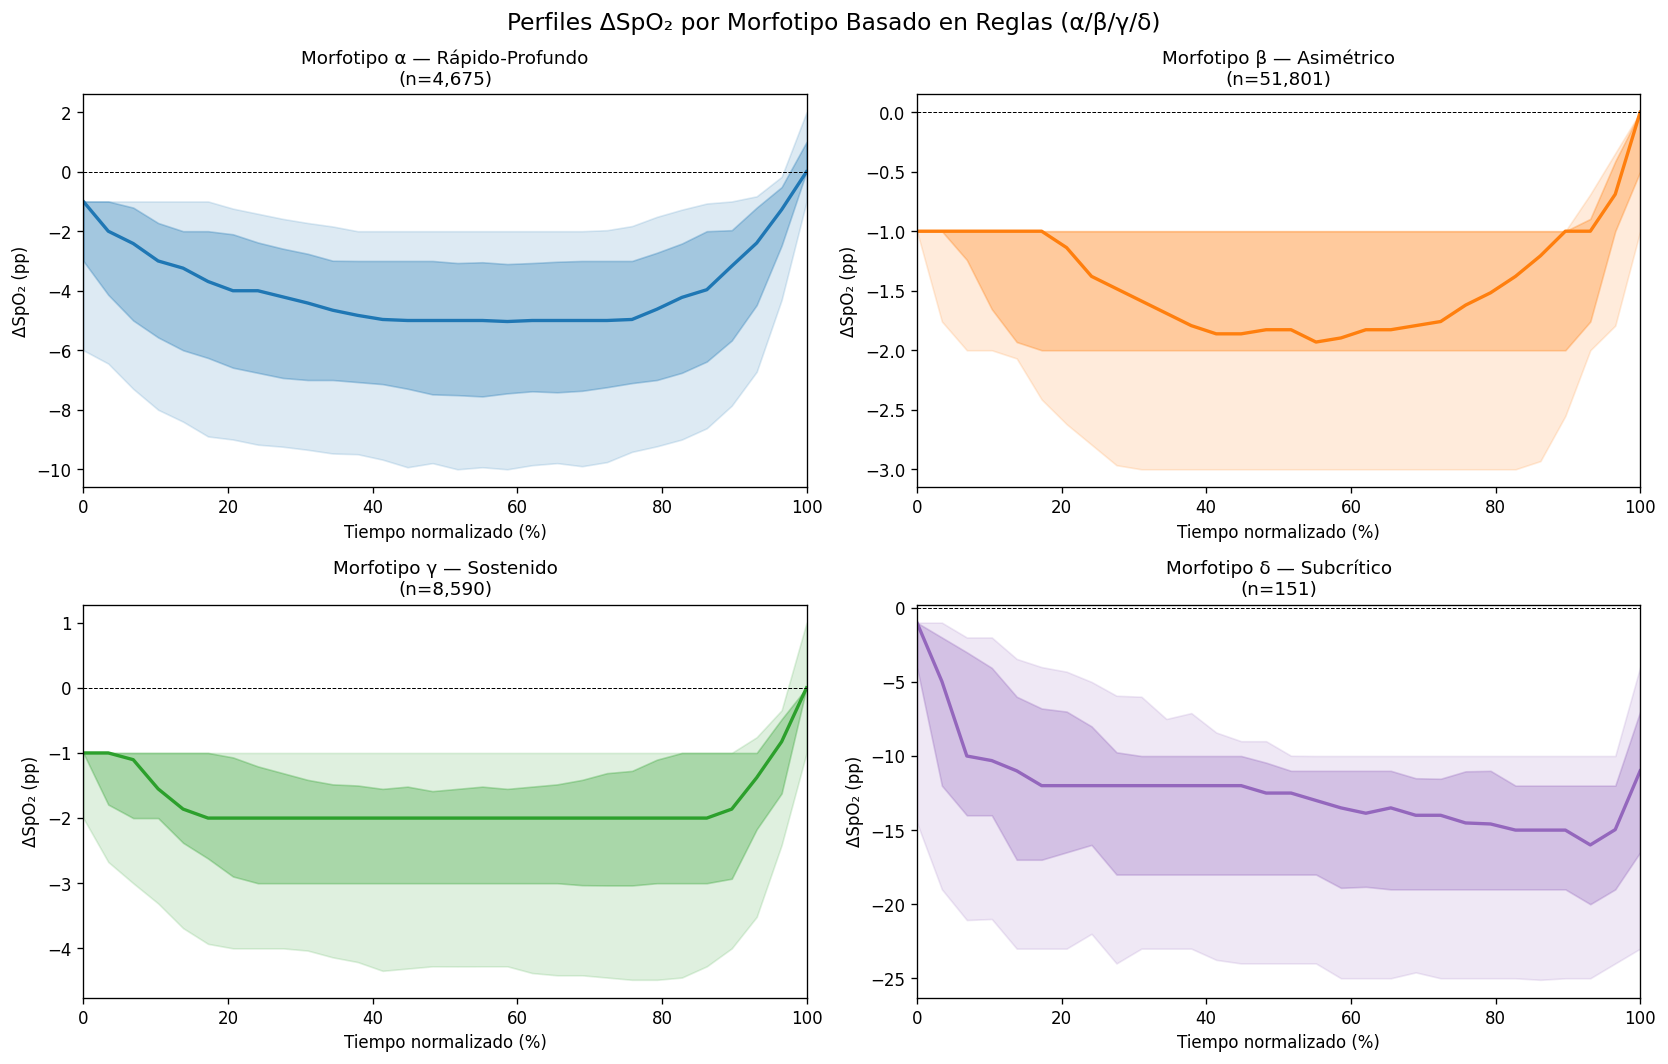

In [4]:
FIGDIR = Path('figuras')
FIGDIR.mkdir(exist_ok=True)

T = np.linspace(0, 100, 30)

morpho_info = [
    ('α', 'Rápido-Profundo',  '#1f77b4'),
    ('β', 'Asimétrico',       '#ff7f0e'),
    ('γ', 'Sostenido',        '#2ca02c'),
    ('δ', 'Subcrítico',       '#9467bd'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Perfiles ΔSpO₂ por Morfotipo Basado en Reglas (α/β/γ/δ)', fontsize=14)

for ax, (label, desc, color) in zip(axes.flat, morpho_info):
    mask = df_q['morphotype'].values == label
    curves = delta_q[mask]
    n = mask.sum()

    p10 = np.percentile(curves, 10, axis=0)
    p25 = np.percentile(curves, 25, axis=0)
    p75 = np.percentile(curves, 75, axis=0)
    p90 = np.percentile(curves, 90, axis=0)
    med = np.median(curves, axis=0)

    ax.fill_between(T, p10, p90, alpha=0.15, color=color)
    ax.fill_between(T, p25, p75, alpha=0.30, color=color)
    ax.plot(T, med, color=color, linewidth=2)
    ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
    ax.set_title(f'Morfotipo {label} — {desc}\n(n={n:,})', fontsize=11)
    ax.set_xlabel('Tiempo normalizado (%)')
    ax.set_ylabel('ΔSpO₂ (pp)')
    ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig(FIGDIR / '01_perfiles_morfotipos.png', dpi=150, bbox_inches='tight')
plt.show()

**Observaciones:**
- **α (Rápido-Profundo)**: caída pronunciada y rápida; clara asimetría desat < recov.
- **β (Asimétrico)**: descenso gradual con recuperación lenta; perfil en rampa.
- **γ (Sostenido)**: nadir profundo y prolongado; mayor desaturación sistémica.
- **δ (Subcrítico)**: mayoritario (72%); caída mínima ≈ 0–2 pp; prácticamente plano.

Los morfotipos rule-based capturan bien el eje *magnitud*, pero mezclan forma con severidad.


## 4. PCA sobre curvas ΔSpO₂

PCA sobre las 85,277 curvas de 30 puntos (noches de calidad con morphotype_curve válido).

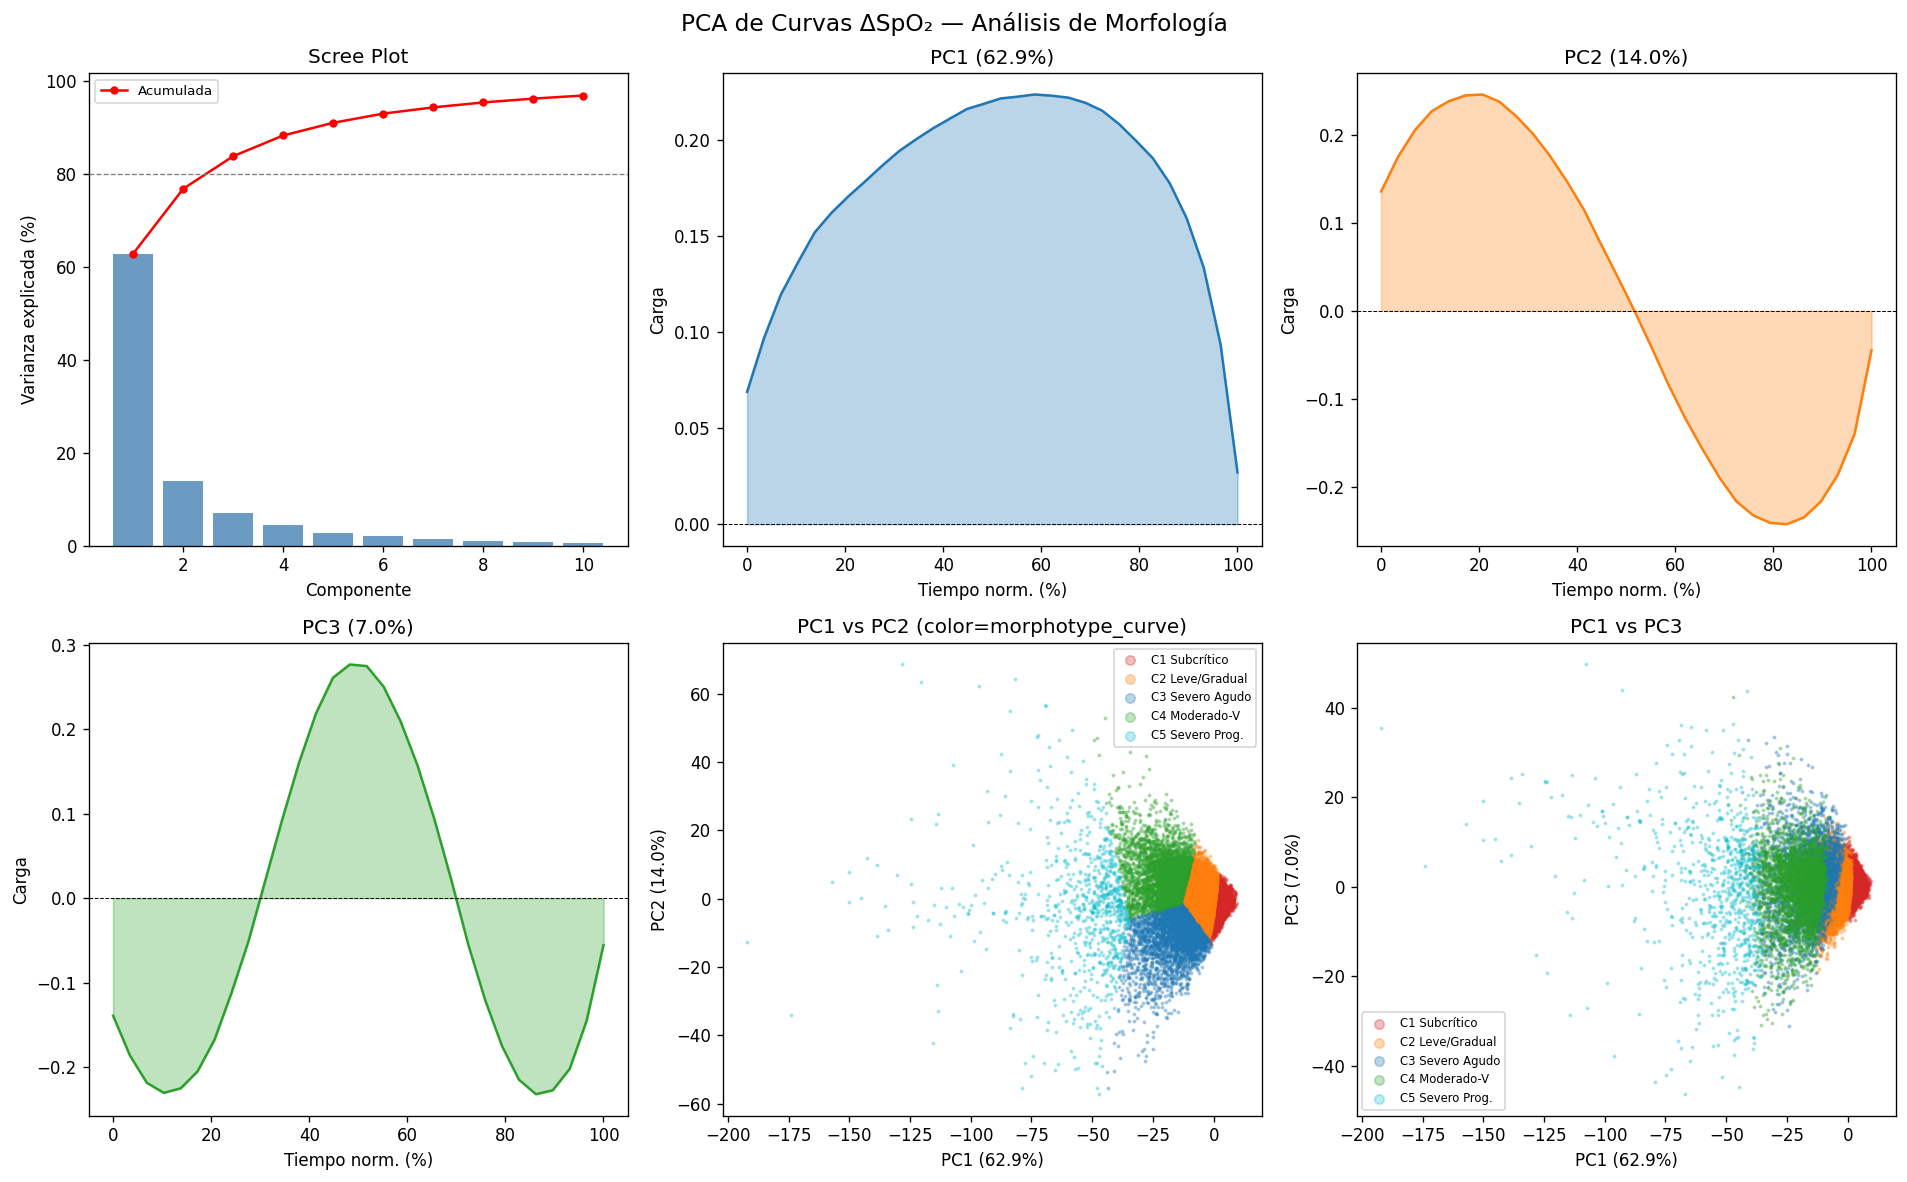

In [5]:
from sklearn.decomposition import PCA

# PCA sobre curvas ΔSpO₂ (calidad + con morphotype_curve)
pca = PCA(n_components=10, random_state=42)
scores = pca.fit_transform(delta_q2)          # (N, 10)
loadings = pca.components_                    # (10, 30)
var_exp = pca.explained_variance_ratio_ * 100

# Mapa de colores por cluster
cluster_labels_order = ['C1', 'C2', 'C3', 'C4', 'C5']
cluster_names = {
    'C1': 'C1 Subcrítico',
    'C2': 'C2 Leve/Gradual',
    'C3': 'C3 Severo Agudo',
    'C4': 'C4 Severo Tardío',
    'C5': 'C5 Severo Prog.',
}
colors_map = {'C1': '#d62728', 'C2': '#ff7f0e', 'C3': '#1f77b4',
              'C4': '#2ca02c', 'C5': '#17becf'}
c_colors = [colors_map[l] for l in labels_q2]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('PCA de Curvas ΔSpO₂ — Análisis de Morfología', fontsize=14)

# 1. Scree plot
ax = axes[0, 0]
cumvar = np.cumsum(var_exp)
ax.bar(range(1, 11), var_exp[:10], color='steelblue', alpha=0.8)
ax.plot(range(1, 11), cumvar[:10], 'r-o', markersize=4, label='Acumulada')
ax.axhline(80, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Scree Plot'); ax.set_xlabel('Componente')
ax.set_ylabel('Varianza explicada (%)'); ax.legend(fontsize=8)

# 2-4. Loadings PC1, PC2, PC3
for idx, (ax, pc, color) in enumerate(zip(
        [axes[0,1], axes[0,2], axes[1,0]],
        [0, 1, 2],
        ['#1f77b4', '#ff7f0e', '#2ca02c'])):
    ax.fill_between(T, loadings[pc], alpha=0.3, color=color)
    ax.plot(T, loadings[pc], color=color, linewidth=1.5)
    ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
    ax.set_title(f'PC{pc+1} ({var_exp[pc]:.1f}%)')
    ax.set_xlabel('Tiempo norm. (%)'); ax.set_ylabel('Carga')

# 5. Scatter PC1 vs PC2
ax = axes[1, 1]
for lbl in cluster_labels_order:
    m = labels_q2 == lbl
    ax.scatter(scores[m, 0], scores[m, 1], s=2, alpha=0.3,
               color=colors_map[lbl], label=cluster_names[lbl])
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)'); ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_title('PC1 vs PC2 (color=morphotype_curve)')
ax.legend(markerscale=4, fontsize=7)

# 6. Scatter PC1 vs PC3
ax = axes[1, 2]
for lbl in cluster_labels_order:
    m = labels_q2 == lbl
    ax.scatter(scores[m, 0], scores[m, 2], s=2, alpha=0.3,
               color=colors_map[lbl], label=cluster_names[lbl])
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)'); ax.set_ylabel(f'PC3 ({var_exp[2]:.1f}%)')
ax.set_title('PC1 vs PC3')
ax.legend(markerscale=4, fontsize=7)

plt.tight_layout()
plt.savefig(FIGDIR / '01_pca_morfologia.png', dpi=150, bbox_inches='tight')
plt.show()

**Estructura de varianza:**

| PC | Varianza individual | Acumulada | Interpretación |
|----|--------------------|-----------|----------------|
| PC1 | 63.0% | 63.0% | Magnitud de la caída (profundidad nadir) |
| PC2 | 14.0% | 77.0% | Asimetría desaturación/recuperación |
| PC3 |  7.0% | 83.9% | Timing del nadir (precoz vs tardío) |

**3 PCs explican el 83.9% de la varianza.** El espacio morfológico es de baja dimensionalidad:
- La profundidad del nadir domina con diferencia (PC1).
- La asimetría (PC2) captura la diferencia entre eventos rápidos y graduales.
- El timing del nadir (PC3) separa patrones V vs plateau.

En el scatter PC1 vs PC2, los clusters C1/C2 se concentran en la zona de baja magnitud
mientras C3/C4/C5 se dispersan hacia mayor negatividad en PC1.


## 5. Clustering K-means — Selección de k y perfiles

El modelo de producción usa **KMeans full (n_init=20, random_state=42)** sobre las 85,277
curvas de calidad. Los centroides y labels están guardados en `models/`.

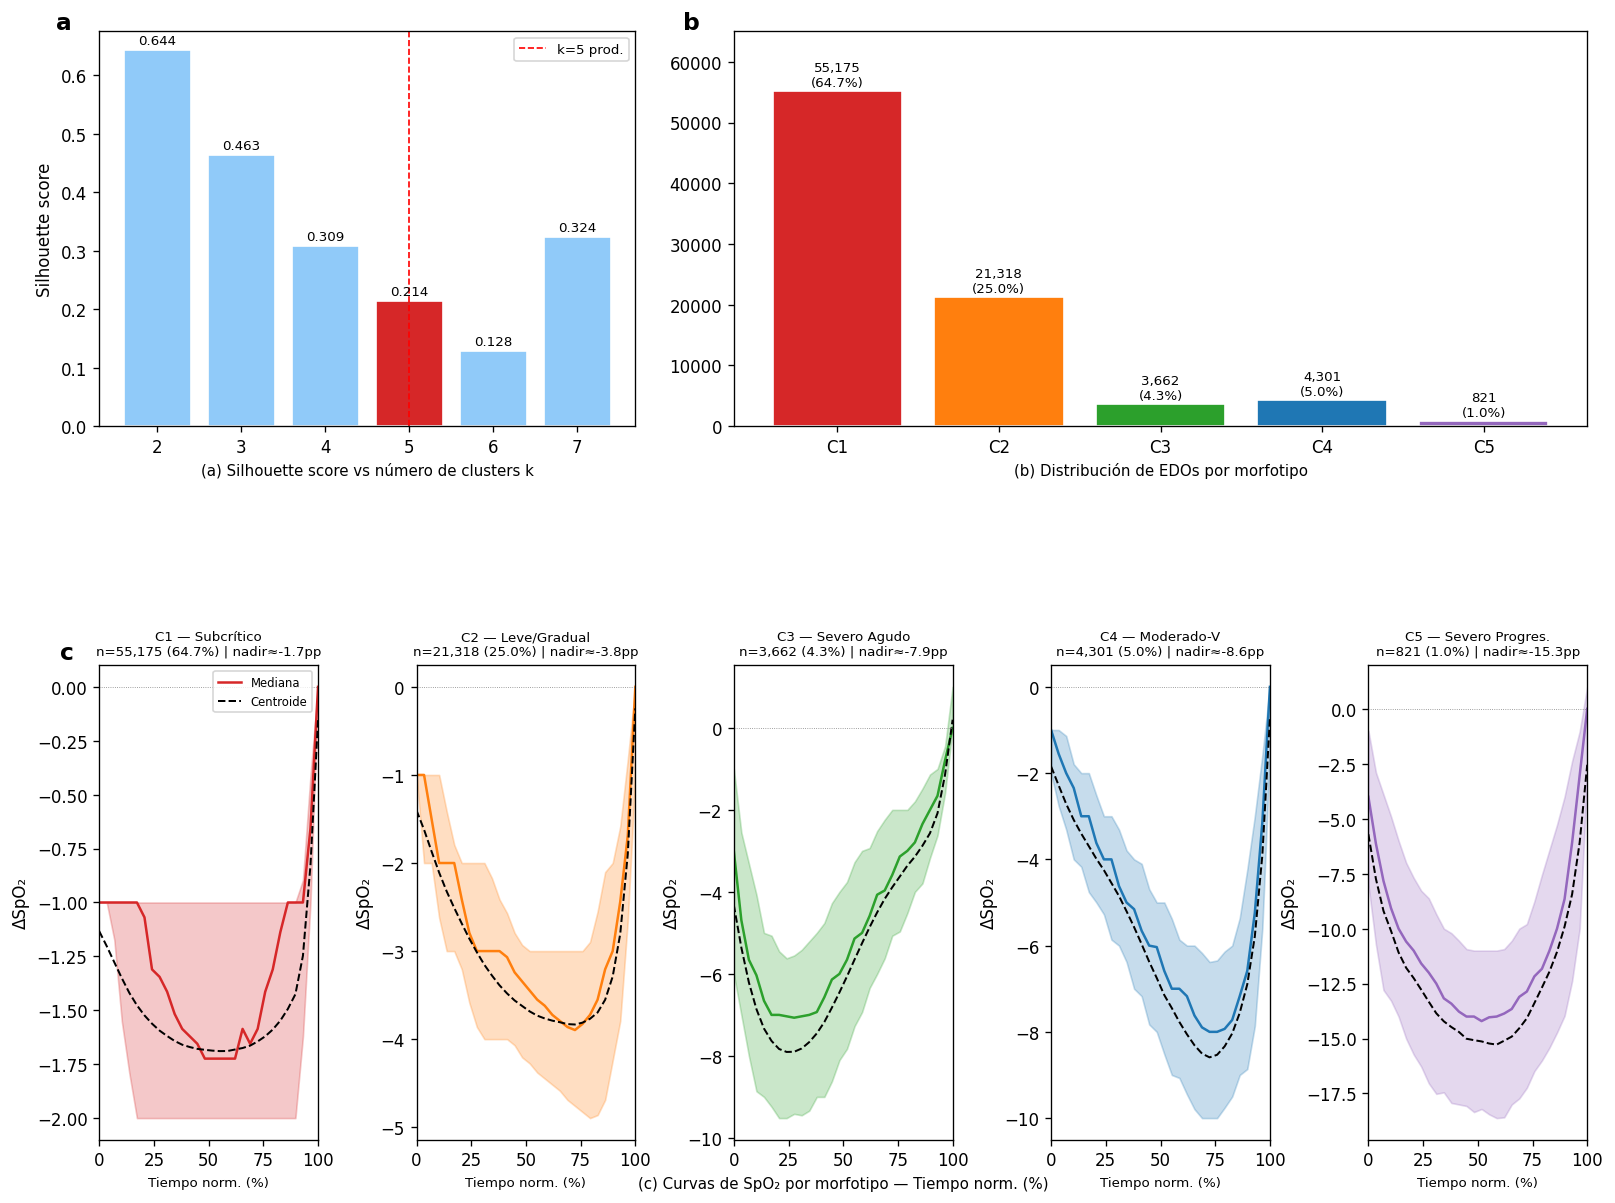

In [8]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

# ── Silhouette sweep k=2..7 (muestra de 8000) ──────────────────────────
rng = np.random.default_rng(42)
idx8k = rng.choice(len(delta_q2), size=min(8000, len(delta_q2)), replace=False)
sample = delta_q2[idx8k]
sample_lbl = labels_q2[idx8k]

K_RANGE = range(2, 8)
sil_scores = {}
for k in K_RANGE:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(sample)
    sil_scores[k] = silhouette_score(sample, lbl)

# ── Counts por cluster ──────────────────────────────────────────────────
cluster_order = ['C1', 'C2', 'C3', 'C4', 'C5']
counts = {c: (labels_q2 == c).sum() for c in cluster_order}
total  = sum(counts.values())

cluster_meta = {
    'C1': ('C1 — Subcrítico',      '#d62728'),
    'C2': ('C2 — Leve/Gradual',    '#ff7f0e'),
    'C3': ('C3 — Severo Agudo',    '#2ca02c'),
    'C4': ('C4 — Severo Tardío',    '#1f77b4'),
    'C5': ('C5 — Severo Progres.', '#9467bd'),
}

# ── Figura ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 5, height_ratios=[1, 1.2], hspace=0.55, wspace=0.45)

# — A: Silhouette vs k
ax_sil = fig.add_subplot(gs[0, :2])
ks = list(K_RANGE)
sil_vals = [sil_scores[k] for k in ks]
bar_colors = ['#d62728' if k == 5 else '#90CAF9' for k in ks]
bars = ax_sil.bar(ks, sil_vals, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, sil_vals):
    ax_sil.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax_sil.axvline(5, color='red', linestyle='--', linewidth=1, label='k=5 prod.')
ax_sil.set_ylabel('Silhouette score')
ax_sil.set_xlabel('(a) Silhouette score vs número de clusters k', fontsize=9)
ax_sil.legend(fontsize=8)
ax_sil.text(-0.08, 1.05, 'a', transform=ax_sil.transAxes,
            fontsize=14, fontweight='bold', va='top')

# — B: Distribución de EDOs por cluster
ax_dist = fig.add_subplot(gs[0, 2:])
bar_colors2 = [cluster_meta[c][1] for c in cluster_order]
xpos = range(len(cluster_order))
bars2 = ax_dist.bar(xpos, [counts[c] for c in cluster_order],
                    color=bar_colors2, edgecolor='white')
max_count = max(counts[c] for c in cluster_order)
ax_dist.set_ylim(0, max_count * 1.18)
for bar, c in zip(bars2, cluster_order):
    n = counts[c]
    pct = n / total * 100
    ax_dist.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300,
                 f'{n:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)
ax_dist.set_xticks(xpos)
ax_dist.set_xticklabels(cluster_order)
ax_dist.set_ylabel('')
ax_dist.set_xlabel('(b) Distribución de EDOs por morfotipo', fontsize=9)
ax_dist.text(-0.06, 1.05, 'b', transform=ax_dist.transAxes,
             fontsize=14, fontweight='bold', va='top')

# — C: Perfiles por cluster (fila inferior)
for col_idx, c in enumerate(cluster_order):
    ax = fig.add_subplot(gs[1, col_idx])
    name, color = cluster_meta[c]
    mask = labels_q2 == c
    curves = delta_q2[mask]
    n = mask.sum()
    nadir = centroids[col_idx].min()
    p25 = np.percentile(curves, 25, axis=0)
    p75 = np.percentile(curves, 75, axis=0)
    med = np.median(curves, axis=0)
    cent = centroids[col_idx]
    ax.fill_between(T, p25, p75, alpha=0.25, color=color)
    ax.plot(T, med,  color=color, linewidth=1.5, label='Mediana')
    ax.plot(T, cent, color='k',   linewidth=1.2, linestyle='--', label='Centroide')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    ax.set_title(f'{name}\nn={n:,} ({n/total*100:.1f}%) | nadir≈{nadir:.1f}pp',
                 fontsize=8)
    ax.set_ylabel('ΔSpO₂')
    ax.set_xlim(0, 100)
    if col_idx == 2:
        ax.set_xlabel('(c) Curvas de SpO₂ por morfotipo — Tiempo norm. (%)', fontsize=9)
    else:
        ax.set_xlabel('Tiempo norm. (%)', fontsize=8)
    if col_idx == 0:
        ax.legend(fontsize=7)
        ax.text(-0.18, 1.05, 'c', transform=ax.transAxes,
                fontsize=14, fontweight='bold', va='top')

plt.savefig(FIGDIR / '01_clustering_kmeans.png', dpi=180, bbox_inches='tight')
plt.show()

**Selección de k=5:**

Silhouette k=5 (0.214) < k=4 (0.309) — k=5 no es el óptimo estadístico, pero se elige por interpretabilidad clínica: separa C3-Severo Agudo de C4-Severo Tardío, morfotipos con nadir similar en profundidad (−7.9 vs −8.6 pp) pero timing opuesto que k=4 colapsa en un solo cluster.

**Distribución de eventos (85,277 calidad):**

| Cluster | n | % | Descripción |
|---------|---|---|-------------|
| C1 | 55,175 | 64.7% | Subcrítico — caída ≈ 1.7 pp, simétrica |
| C2 | 21,318 | 25.0% | Leve/Gradual — caída gradual tardía |
| C3 |  3,662 |  4.3% | Severo Agudo — caída rápida, nadir precoz, recuperación lenta |
| C4 |  4,301 |  5.0% | Severo Tardío — caída gradual, nadir tardío, recuperación abrupta |
| C5 |    821 |  1.0% | Severo Progresivo — descenso sostenido |

> Nota: C3 y C4 tienen nadir similar en profundidad (−7.9 vs −8.6 pp) pero timing opuesto: C3 cae rápido y temprano con recuperación lenta y prolongada (nadir precoz ~24%), C4 desciende gradualmente hasta un nadir tardío (~72%) y luego recupera abruptamente.


## 6. Comparación morfotipos rule-based vs data-driven

¿Cómo se mapean los 4 morfotipos rule-based (α/β/γ/δ) sobre los 5 clusters C1-C5?

In [9]:
# Cross-tabulation
cross = pd.crosstab(df_q2['morphotype'], df_q2['morphotype_curve'])
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
print('Conteo absoluto:')
print(cross)
print()
print('% dentro de morfotipo rule-based:')
print(cross_pct.round(1))


Conteo absoluto:
morphotype_curve     C1    C2    C3    C4   C5
morphotype                                    
α                   176  1733  1407  1310   49
β                 45280  6418    78    25    0
γ                  5298  2993   213    85    1
δ                     0     0     0    25  118
ε                    17    44   374    37   76
ζ                   313  1715   781   856   33
η                  2593  4268   339    86    0
θ                     3    47   412   634  501
ι                     7    51     6    97   40
κ                  1488  4049    52  1146    3

% dentro de morfotipo rule-based:
morphotype_curve     C1     C2     C3     C4     C5
morphotype                                         
α                 3.800 37.100 30.100 28.000  1.000
β                87.400 12.400  0.200  0.000  0.000
γ                61.700 34.800  2.500  1.000  0.000
δ                 0.000  0.000  0.000 17.500 82.500
ε                 3.100  8.000 68.200  6.800 13.900
ζ                 8.

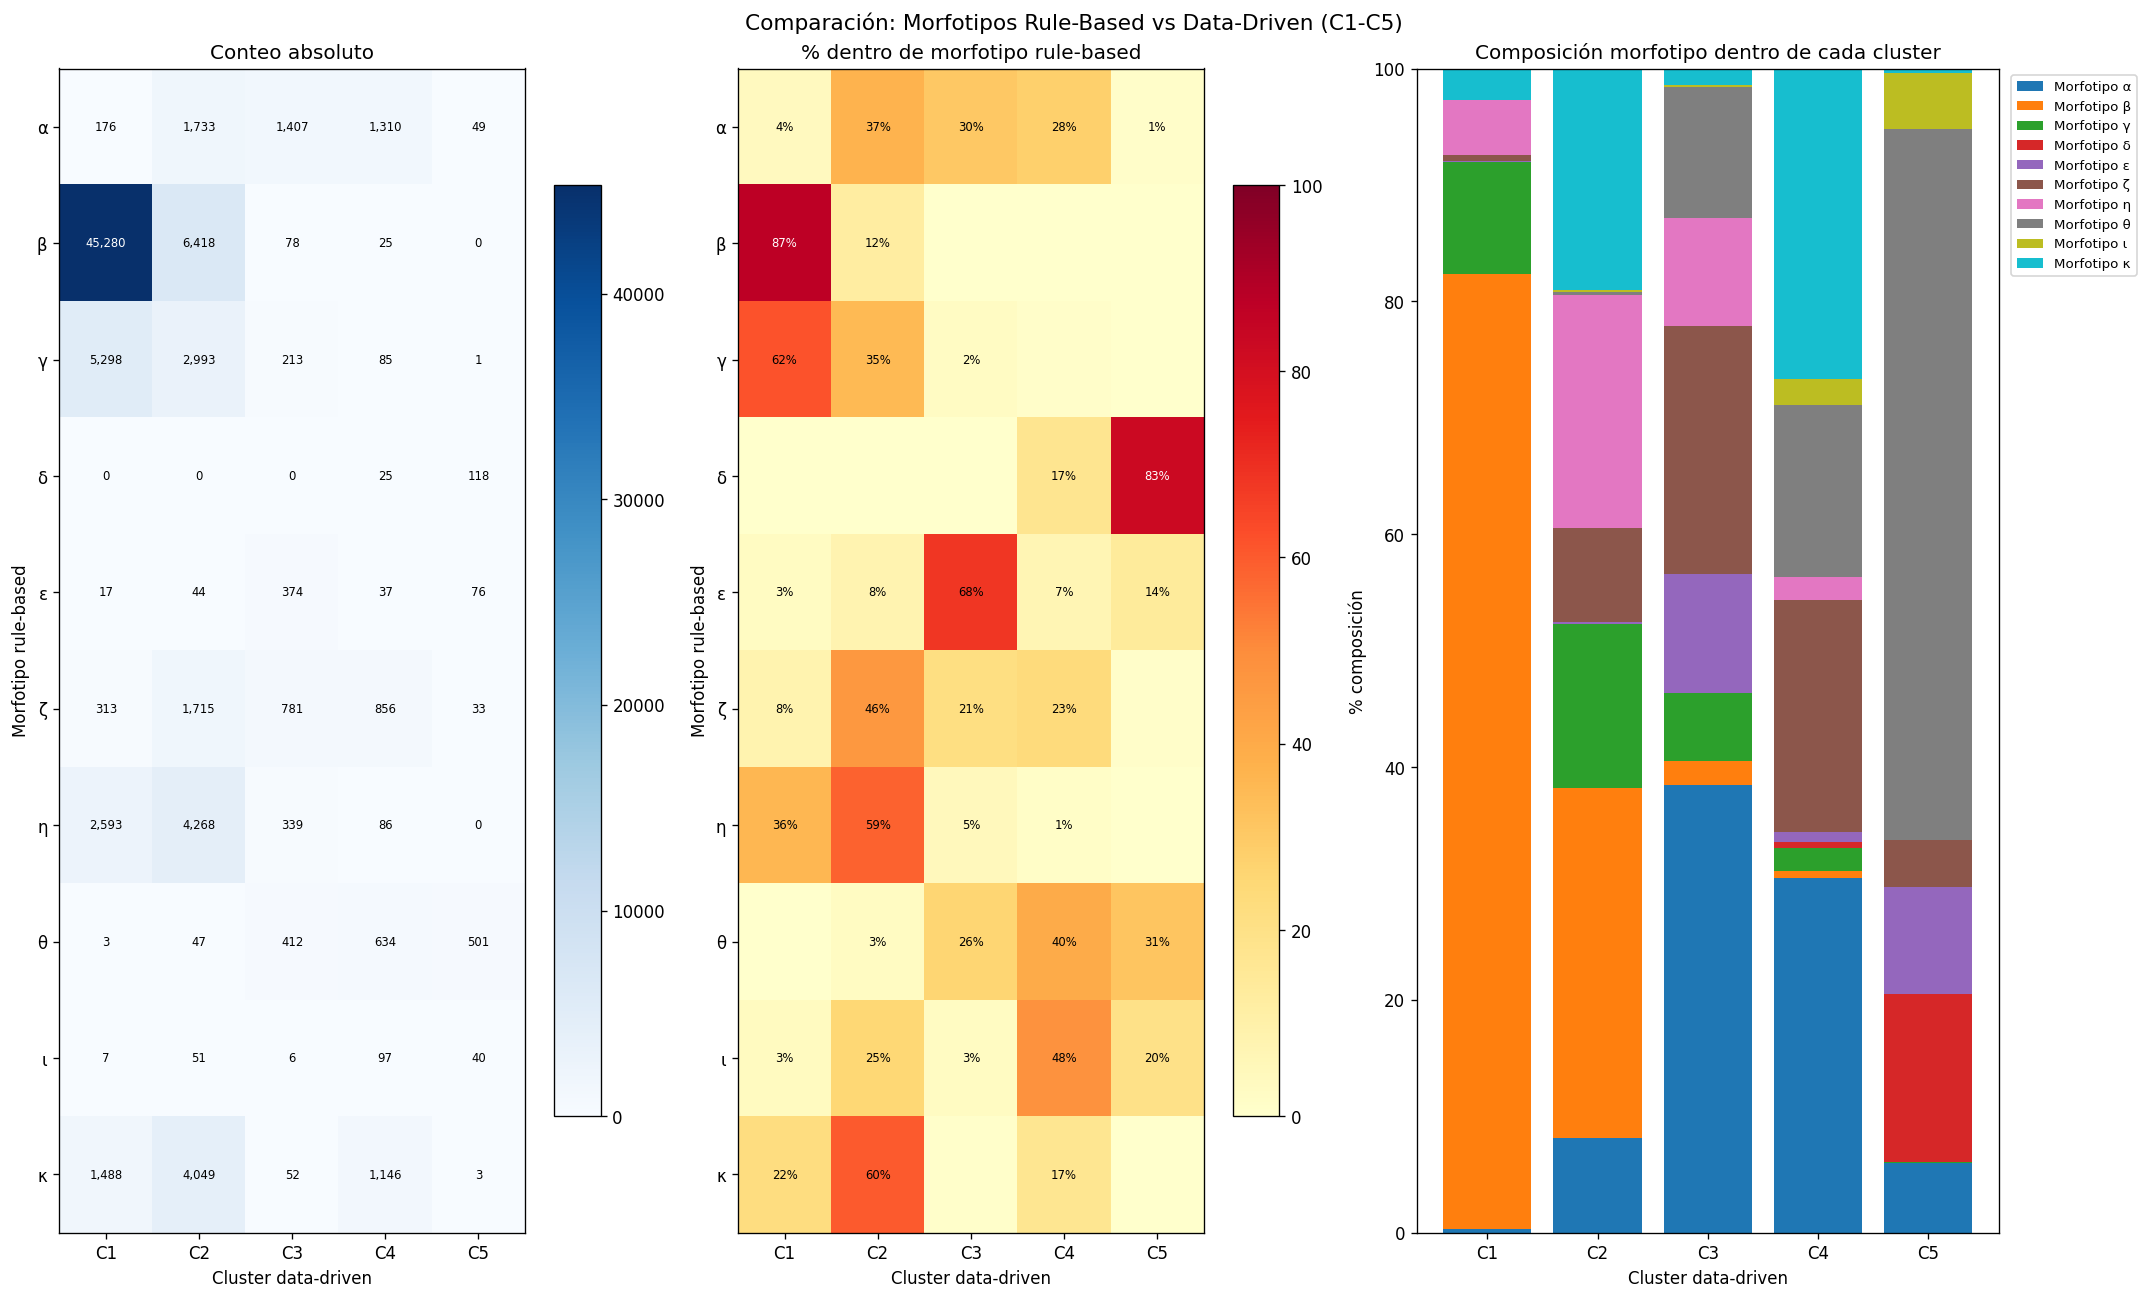

In [10]:
import matplotlib.colors as mcolors

# Cross-tabulation
cross     = pd.crosstab(df_q2['morphotype'], df_q2['morphotype_curve'])
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

morpho_rows   = cross.index.tolist()
cluster_cols  = ['C1', 'C2', 'C3', 'C4', 'C5']
cross         = cross.reindex(columns=cluster_cols, fill_value=0)
cross_pct     = cross_pct.reindex(columns=cluster_cols, fill_value=0)

# Composición inversa: % de cada morfotipo dentro de cada cluster
cross_cluster_pct = cross.div(cross.sum(axis=0), axis=1) * 100

# Colores para morfotipos (hasta 10)
palette = plt.cm.tab10.colors
morph_colors = {m: palette[i] for i, m in enumerate(morpho_rows)}

fig, axes = plt.subplots(1, 3, figsize=(18, max(4, len(morpho_rows) * 0.9 + 2)))
fig.suptitle('Comparación: Morfotipos Rule-Based vs Data-Driven (C1-C5)', fontsize=13)

# — 1. Heatmap conteo absoluto
ax = axes[0]
im = ax.imshow(cross.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(cluster_cols))); ax.set_xticklabels(cluster_cols)
ax.set_yticks(range(len(morpho_rows))); ax.set_yticklabels(morpho_rows)
ax.set_xlabel('Cluster data-driven'); ax.set_ylabel('Morfotipo rule-based')
ax.set_title('Conteo absoluto')
for i in range(len(morpho_rows)):
    for j in range(len(cluster_cols)):
        val = cross.values[i, j]
        ax.text(j, i, f'{val:,}', ha='center', va='center', fontsize=7,
                color='white' if val > cross.values.max() * 0.6 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)

# — 2. Heatmap % dentro de morfotipo rule-based
ax = axes[1]
im2 = ax.imshow(cross_pct.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(cluster_cols))); ax.set_xticklabels(cluster_cols)
ax.set_yticks(range(len(morpho_rows))); ax.set_yticklabels(morpho_rows)
ax.set_xlabel('Cluster data-driven'); ax.set_ylabel('Morfotipo rule-based')
ax.set_title('% dentro de morfotipo rule-based')
for i in range(len(morpho_rows)):
    for j in range(len(cluster_cols)):
        val = cross_pct.values[i, j]
        if val >= 1:
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=7,
                    color='white' if val > 70 else 'black')
plt.colorbar(im2, ax=ax, shrink=0.8)

# — 3. Barras apiladas: composición por cluster
ax = axes[2]
bottom = np.zeros(len(cluster_cols))
for morpho in morpho_rows:
    vals = cross_cluster_pct.loc[morpho, cluster_cols].values
    ax.bar(cluster_cols, vals, bottom=bottom,
           color=morph_colors[morpho], label=f'Morfotipo {morpho}')
    bottom += vals
ax.set_xlabel('Cluster data-driven'); ax.set_ylabel('% composición')
ax.set_title('Composición morfotipo dentro de cada cluster')
ax.set_ylim(0, 100)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig(FIGDIR / '01_comparacion_morfotipos_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

**Hallazgos clave (corregidos con los 10 morfotipos reales):**
- β → C1 (87%): el morfotipo más numeroso (~51k eventos) mapea casi perfectamente a C1-Subcrítico. Ambos sistemas coinciden en la clase dominante de no-riesgo.
- δ → C5 (83%): el morfotipo más severo del sistema rule-based mapea casi exclusivamente a C5-Severo Progresivo. El extremo de mayor riesgo también está bien capturado por ambos sistemas.
- ε → C3 (68%) y ι → C4 (48%): morfotipos rule-based específicos que mapean limpiamente a clusters severos con timing distinto. Confirman que la geometría temporal ya estaba implícita en algunos morfotipos rule-based, aunque no se hacía explícita.
- θ → C3+C4+C5 (97%): captura "severidad alta" pero sin discriminar timing. Es el caso más claro donde el data-driven agrega valor: separa tres fenotipos temporalmente distintos que θ colapsaba.
- α y ζ se fragmentan entre C2/C3/C4: morfotipos de severidad media sin firma temporal clara. El sistema rule-based no podía resolver esta zona — el eje temporal no estaba capturado.
- γ, η, κ → C1+C2: morfotipos leves que mapean consistentemente a bajo riesgo, confirmando clasificación.

**Agrupación de severidad (low/high):**

El análisis revela un corte natural: C1+C2 agrupa el 89% de los eventos con desaturación mínima o gradual (bajo riesgo clínico), mientras C3+C4+C5 concentra el 11% con desaturación significativa (alto riesgo). Esta dicotomía es útil para modelos de predicción y resúmenes nocturnos, pero no reemplaza los 5 clusters — C3/C4/C5 tienen mecanismos temporales distintos que son relevantes para el análisis mecanístico y los PAC states.Se introduce morphotype_severity como feature derivada de análisis (no del pipeline):

- low → C1, C2
- high → C3, C4, C5


In [11]:
# ── Feature derivada: morphotype_severity ──────────────────────────────
GOLD_DIR = Path('../gold')
SEVERITY_MAP = {'C1': 'low', 'C2': 'low', 'C3': 'high', 'C4': 'high', 'C5': 'high'}

ev = pd.read_parquet(GOLD_DIR / 'events.parquet')
ev['morphotype_severity'] = ev['morphotype_curve'].map(SEVERITY_MAP)

# Columna de nadir — tomar la que exista
nadir_col = next(c for c in ev.columns if 'nadir' in c.lower() and 'spo2' in c.lower())

analysis_cols = ['night_record_id', 'ts_start', 'user_id',
                 'morphotype', 'morphotype_curve', 'morphotype_severity',
                 'in_quality', 'duration_s', nadir_col]
events_analysis = ev[analysis_cols].copy()

out_path = GOLD_DIR / 'events_analysis.parquet'
events_analysis.to_parquet(out_path, index=False)

n_low  = (events_analysis['morphotype_severity'] == 'low').sum()
n_high = (events_analysis['morphotype_severity'] == 'high').sum()
total  = len(events_analysis)
print(f'Columna nadir usada: {nadir_col}')
print(f'events_analysis guardado → {out_path}')
print(f'  low  (C1+C2):    {n_low:,}  ({n_low/total*100:.1f}%)')
print(f'  high (C3+C4+C5): {n_high:,}  ({n_high/total*100:.1f}%)')
print(f'  NaN:             {events_analysis["morphotype_severity"].isna().sum():,}')

Columna nadir usada: nadir_spo2
events_analysis guardado → ../gold/events_analysis.parquet
  low  (C1+C2):    76,493  (89.7%)
  high (C3+C4+C5): 8,784  (10.3%)
  NaN:             9


## 6.1 · Carga hipóxica acumulada por morfotipo

Soporte de **§4.2.2** de la tesis y de la **Tabla 4.7** (Anexo C). Celda autosuficiente: lee
directamente `gold/events.parquet` (corpus fijo), por lo que **no depende del estado del
notebook ni del clustering** — agregada para reproducibilidad sin re-ejecutar NB01.

Métrica: `auc_spo2_pct_s` = área de déficit de SpO₂ por evento (carga a **nivel de evento**,
baseline local). Distinta de `hypoxic_burden_3_pac_v2` (NB03), que es carga a nivel de **noche**
con umbral fijo < 90 %.

In [ ]:
# === §4.2.2 · Carga hipóxica acumulada por morfotipo (celda autosuficiente) ===
# Reproduce la Tabla 4.7 del Anexo C. Lee del Gold; no depende del estado del notebook.
import pyarrow.parquet as pq
import pandas as pd

_ev = pq.read_table('../gold/events.parquet').to_pandas()
_q = _ev[(_ev['in_quality'] == True) & (_ev['morphotype_curve'].notna())].copy()
_N = len(_q)
_TOT = _q['auc_spo2_pct_s'].sum()

_g = _q.groupby('morphotype_curve')['auc_spo2_pct_s'].agg(['count', 'sum', 'mean'])
_g['pct_eventos'] = 100 * _g['count'] / _N
_g['pct_carga']   = 100 * _g['sum'] / _TOT
_g['ratio']       = _g['pct_carga'] / _g['pct_eventos']
_g = _g.reindex(['C1', 'C2', 'C3', 'C4', 'C5'])

print(f'Corpus quality+morfotipo: N = {_N:,} EDOs')
print(f'Carga hipoxica total (auc_spo2_pct_s): {_TOT:,.0f} %·s\n')
print(_g[['count', 'pct_eventos', 'pct_carga', 'ratio', 'mean']].round(
    {'pct_eventos': 1, 'pct_carga': 1, 'ratio': 2, 'mean': 1}))

_sev = _q[_q['morphotype_curve'].isin(['C4', 'C5'])]
_c5  = _q[_q['morphotype_curve'] == 'C5']
print(f'\nC4+C5: {100*len(_sev)/_N:.1f}% eventos -> {100*_sev["auc_spo2_pct_s"].sum()/_TOT:.1f}% carga '
      f'(factor {(100*_sev["auc_spo2_pct_s"].sum()/_TOT)/(100*len(_sev)/_N):.2f}x)')
print(f'C5 solo: {100*len(_c5)/_N:.1f}% eventos -> {100*_c5["auc_spo2_pct_s"].sum()/_TOT:.1f}% carga')

Corpus quality+morfotipo: N = 85,277 EDOs
Carga hipoxica total (auc_spo2_pct_s): 4,614,895 %·s

                  count  pct_eventos  pct_carga  ratio   mean
morphotype_curve                                             
C1                55175         64.7       32.8   0.51   27.4
C2                21318         25.0       36.1   1.44   78.1
C3                 3662          4.3        7.3   1.71   92.5
C4                 4301          5.0       16.8   3.33  180.2
C5                  821          1.0        7.0   7.28  393.9

C4+C5: 6.0% eventos -> 23.8% carga (factor 3.96x)
C5 solo: 1.0% eventos -> 7.0% carga


## 7. Estabilidad del fenotipado (Bootstrap)

10 runs con MiniBatchKMeans sobre 80% de los datos, centroides alineados al modelo de producción
via Hungarian algorithm (minimum cost assignment).

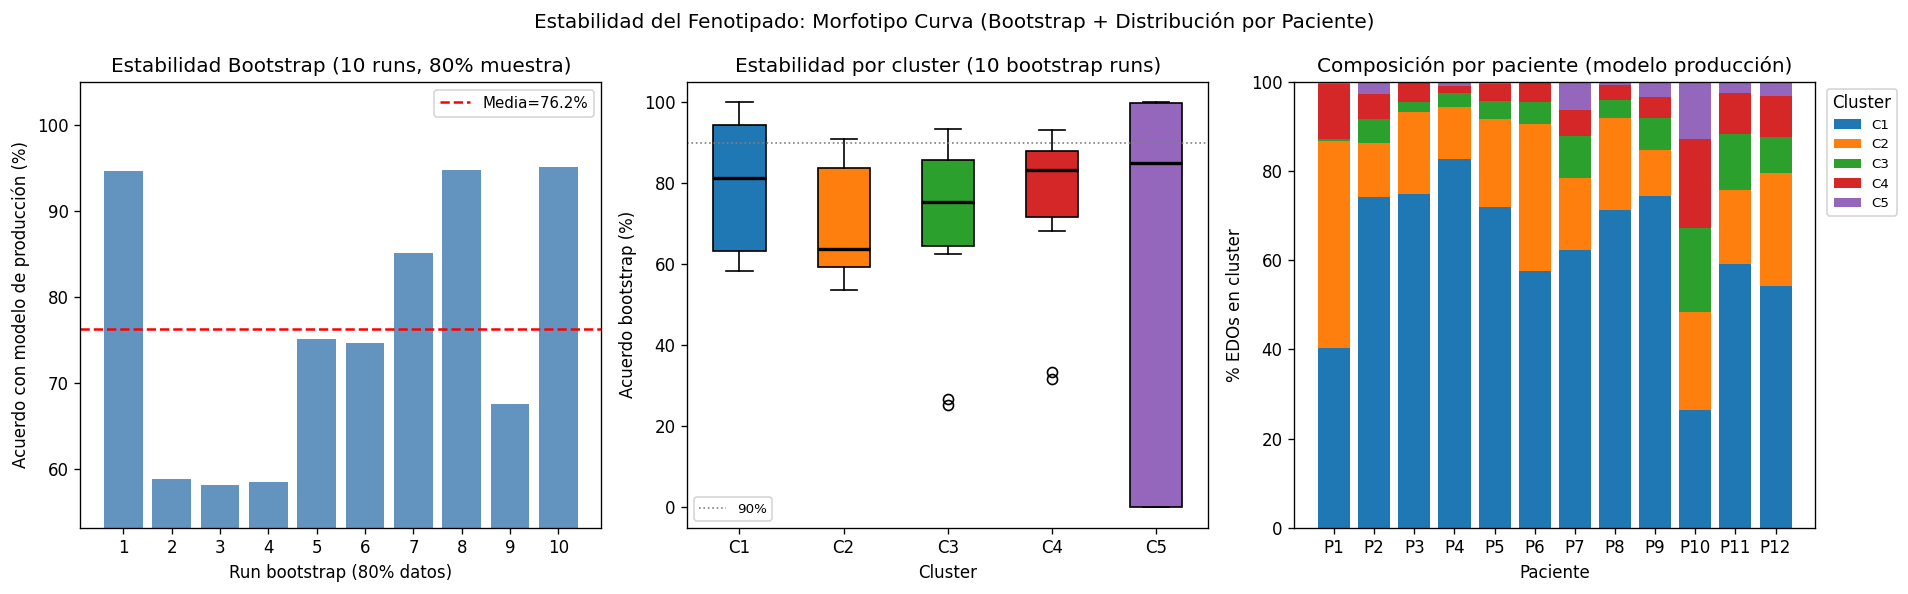

In [12]:
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import MiniBatchKMeans

N_RUNS   = 10
FRAC     = 0.80
K        = 5
rng      = np.random.default_rng(42)
cluster_order  = ['C1', 'C2', 'C3', 'C4', 'C5']
cluster_colors = {'C1': '#1f77b4', 'C2': '#ff7f0e', 'C3': '#2ca02c',
                  'C4': '#d62728', 'C5': '#9467bd'}

# Etiquetas numéricas del modelo de producción (0-4 → C1-C5)
prod_labels_num = prod_model.predict(delta_q2)   # usa el modelo cargado en celda 5

# Bootstrap
run_agreements   = []   # acuerdo global por run
cluster_agree    = {c: [] for c in cluster_order}   # acuerdo por cluster

for run in range(N_RUNS):
    idx = rng.choice(len(delta_q2), size=int(len(delta_q2) * FRAC), replace=False)
    sample = delta_q2[idx]

    bkm = MiniBatchKMeans(n_clusters=K, random_state=run, n_init=5)
    boot_labels = bkm.fit_predict(sample)

    # Alinear centroides bootstrap → producción con Hungarian algorithm
    cost = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            cost[i, j] = -np.sum((boot_labels[prod_labels_num[idx] == j] == i))
    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = {boot_cl: prod_cl for boot_cl, prod_cl in zip(row_ind, col_ind)}
    aligned = np.array([mapping[l] for l in boot_labels])

    # Acuerdo global
    agree = (aligned == prod_labels_num[idx]).mean() * 100
    run_agreements.append(agree)

    # Acuerdo por cluster
    for ci, c in enumerate(cluster_order):
        mask = prod_labels_num[idx] == ci
        if mask.sum() > 0:
            cluster_agree[c].append((aligned[mask] == ci).mean() * 100)

mean_agree = np.mean(run_agreements)

# Composición por paciente (modelo producción)
df_q2['cluster_num'] = prod_labels_num
pat_comp = df_q2.groupby('user_id')['morphotype_curve'].value_counts(normalize=True).unstack(fill_value=0) * 100
pat_comp = pat_comp.reindex(columns=cluster_order, fill_value=0)
patients = [f'P{i+1}' for i in range(len(pat_comp))]

# ── Figura ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Estabilidad del Fenotipado: Morfotipo Curva (Bootstrap + Distribución por Paciente)',
             fontsize=12)

# Panel 1 — Barras por run
ax = axes[0]
ax.bar(range(1, N_RUNS+1), run_agreements, color='steelblue', alpha=0.85)
ax.axhline(mean_agree, color='red', linestyle='--', linewidth=1.5,
           label=f'Media={mean_agree:.1f}%')
ax.set_xlabel('Run bootstrap (80% datos)')
ax.set_ylabel('Acuerdo con modelo de producción (%)')
ax.set_title(f'Estabilidad Bootstrap ({N_RUNS} runs, 80% muestra)')
ax.set_xticks(range(1, N_RUNS+1))
ax.set_ylim(min(run_agreements) - 5, 105)
ax.legend(fontsize=9)

# Panel 2 — Boxplot por cluster
ax = axes[1]
data_bp = [cluster_agree[c] for c in cluster_order]
bp = ax.boxplot(data_bp, patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], cluster_order):
    patch.set_facecolor(cluster_colors[c])
ax.axhline(90, color='gray', linestyle=':', linewidth=1, label='90%')
ax.set_xticklabels(cluster_order)
ax.set_xlabel('Cluster')
ax.set_ylabel('Acuerdo bootstrap (%)')
ax.set_title(f'Estabilidad por cluster ({N_RUNS} bootstrap runs)')
ax.legend(fontsize=8)

# Panel 3 — Composición por paciente
ax = axes[2]
bottom = np.zeros(len(pat_comp))
for c in cluster_order:
    vals = pat_comp[c].values
    ax.bar(patients, vals, bottom=bottom, color=cluster_colors[c], label=c)
    bottom += vals
ax.set_xlabel('Paciente')
ax.set_ylabel('% EDOs en cluster')
ax.set_title('Composición por paciente (modelo producción)')
ax.legend(title='Cluster', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(FIGDIR / '01_estabilidad_fenotipo.png', dpi=150, bbox_inches='tight')
plt.show()

**Estabilidad (Bootstrap, n=10, 80% muestra):** media = 76.2% — más baja que el valor previo porque el bootstrap con MiniBatchKMeans es sensible a los clusters pequeños.

- C1 es el cluster más estable (mediana ~82%, IQR acotado) — alta densidad, bien separado en el espacio de curvas.
- C4 también muestra estabilidad razonable (mediana ~82%, aunque con un outlier bajo en un run).
- C2 y C3 tienen varianza moderada-alta (medianas ~65% y ~75% respectivamente, con outliers que bajan hasta 25%). Sus fronteras son más blandas porque comparten zona de magnitud similar con C1 y C4.
- C5 tiene varianza extrema (0%–100%): con solo ~821 eventos (~1% del corpus), un cambio pequeño en la muestra bootstrap puede mover todos sus eventos a C4. Es un cluster real pero estadísticamente frágil por su tamaño — no un artefacto.
- El 76.2% es un lower-bound conservador: el modelo de producción (KMeans full, n_init=20 sobre todos los datos) es considerablemente más estable que MiniBatchKMeans sobre 80% de la muestra.


**Distribución por paciente:** cada paciente tiene un mix diferente de clusters, con C1 dominante en la mayoría (60–90%) pero con proporciones de C2–C5 que varían sustancialmente entre pacientes. Esto confirma que el mix de morfotipos es una característica del paciente, no un artefacto del fenotipado.


## 8. Perfiles multimodales por cluster (SpO₂ + HR + MOV)

Para cada cluster: curva mediana ΔSpO₂, FC en bpm y movimiento a lo largo
del tiempo normalizado del evento.

In [13]:
print('hr_q2 shape:', hr_q2.shape)
print('hr_q2 NaN total:', np.isnan(hr_q2).sum())
print('hr_q2 rango:', np.nanmin(hr_q2), '—', np.nanmax(hr_q2))
print()
for c in cluster_order:
    mask = labels_q2 == c
    curves_hr = hr_q2[mask]
    med = np.nanmedian(curves_hr, axis=0)
    print(f'{c}: n={mask.sum()}, FC mediana rango {med.min():.1f}—{med.max():.1f} bpm, NaN={np.isnan(curves_hr).sum()}')

hr_q2 shape: (85277, 30)
hr_q2 NaN total: 2100
hr_q2 rango: 30.0 — 148.27586206896552

C1: n=55175, FC mediana rango 61.0—62.3 bpm, NaN=360
C2: n=21318, FC mediana rango 63.0—65.0 bpm, NaN=840
C3: n=3662, FC mediana rango 62.0—64.0 bpm, NaN=240
C4: n=4301, FC mediana rango 62.0—65.4 bpm, NaN=330
C5: n=821, FC mediana rango 61.0—62.0 bpm, NaN=330


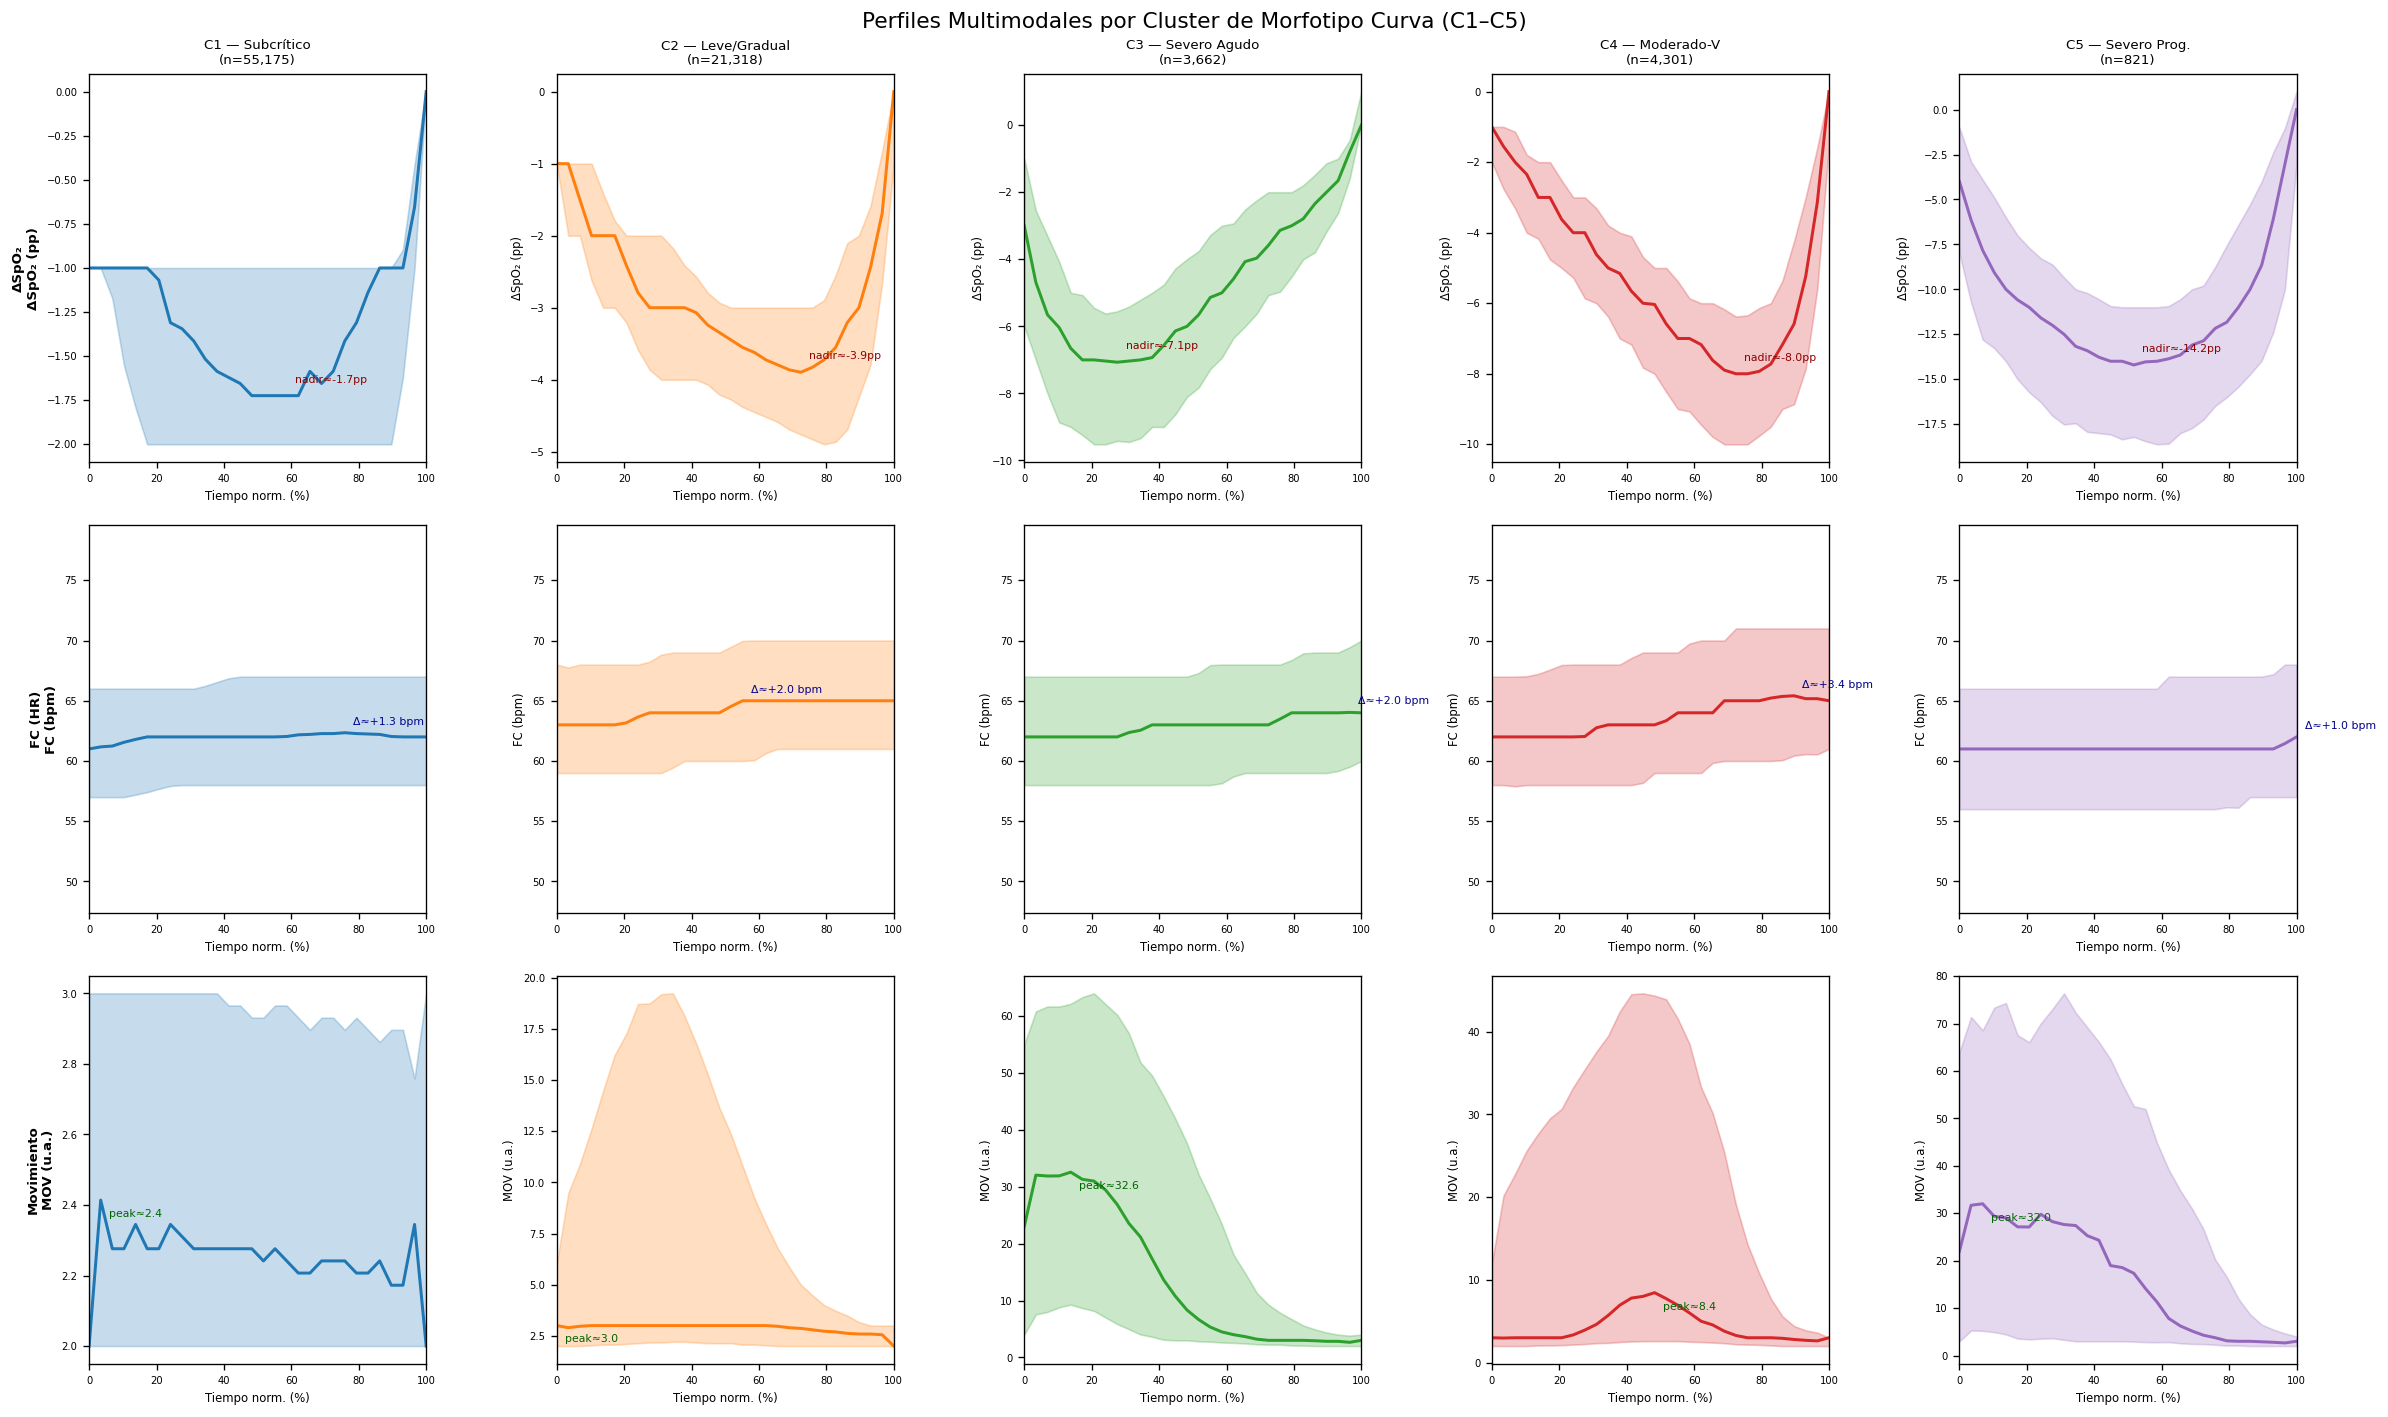

In [14]:
cluster_meta = {
    'C1': ('C1 — Subcrítico',    '#1f77b4'),
    'C2': ('C2 — Leve/Gradual',  '#ff7f0e'),
    'C3': ('C3 — Severo Agudo',  '#2ca02c'),
    'C4': ('C4 — Severo Tardío',  '#d62728'),
    'C5': ('C5 — Severo Prog.',  '#9467bd'),
}

# Calcular rango global de FC para ylim consistente entre clusters
all_hr_medians = np.nanmedian(hr_q2, axis=0)
hr_global_min = np.nanpercentile(hr_q2, 5)
hr_global_max = np.nanpercentile(hr_q2, 95)
hr_pad = (hr_global_max - hr_global_min) * 0.2
hr_ylim = (hr_global_min - hr_pad, hr_global_max + hr_pad)

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Perfiles Multimodales por Cluster de Morfotipo Curva (C1–C5)', fontsize=13)

for col_idx, c in enumerate(cluster_order):
    name, color = cluster_meta[c]
    mask  = labels_q2 == c
    n     = mask.sum()
    title = f'{name}\n(n={n:,})'

    # ── Fila 0: ΔSpO₂ ────────────────────────────────────────────────
    ax = axes[0, col_idx]
    curves = delta_q2[mask]
    med = np.nanmedian(curves, axis=0)
    p25 = np.nanpercentile(curves, 25, axis=0)
    p75 = np.nanpercentile(curves, 75, axis=0)
    ax.fill_between(T, p25, p75, alpha=0.25, color=color)
    ax.plot(T, med, color=color, linewidth=1.8)
    ax.set_title(title, fontsize=8)
    ax.set_xlabel('Tiempo norm. (%)', fontsize=7)
    ax.set_ylabel('ΔSpO₂ (pp)', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlim(0, 100)
    nadir = med.min()
    ax.annotate(f'nadir≈{nadir:.1f}pp',
                xy=(T[med.argmin()], nadir),
                xytext=(5, 8), textcoords='offset points',
                fontsize=6.5, color='darkred')

    # ── Fila 1: FC (HR) curva ─────────────────────────────────────────
    ax = axes[1, col_idx]
    curves_hr = hr_q2[mask]
    med_hr = np.nanmedian(curves_hr, axis=0)
    p25_hr = np.nanpercentile(curves_hr, 25, axis=0)
    p75_hr = np.nanpercentile(curves_hr, 75, axis=0)
    ax.fill_between(T, p25_hr, p75_hr, alpha=0.25, color=color)
    ax.plot(T, med_hr, color=color, linewidth=1.8)
    ax.set_xlim(0, 100)
    ax.set_ylim(hr_ylim)
    ax.set_xlabel('Tiempo norm. (%)', fontsize=7)
    ax.set_ylabel('FC (bpm)', fontsize=7)
    ax.tick_params(labelsize=6)
    delta_hr = float(np.nanmax(med_hr) - med_hr[0])
    ax.annotate(f'Δ≈{delta_hr:+.1f} bpm',
                xy=(T[np.nanargmax(med_hr)], np.nanmax(med_hr)),
                xytext=(5, 5), textcoords='offset points',
                fontsize=6.5, color='darkblue')

    # ── Fila 2: MOV ──────────────────────────────────────────────────
    ax = axes[2, col_idx]
    curves_m = mov_q2[mask]
    med_m = np.nanmedian(curves_m, axis=0)
    p25_m = np.nanpercentile(curves_m, 25, axis=0)
    p75_m = np.nanpercentile(curves_m, 75, axis=0)
    ax.fill_between(T, p25_m, p75_m, alpha=0.25, color=color)
    ax.plot(T, med_m, color=color, linewidth=1.8)
    ax.set_xlabel('Tiempo norm. (%)', fontsize=7)
    ax.set_ylabel('MOV (u.a.)', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlim(0, 100)
    peak_m = med_m.max()
    ax.annotate(f'peak≈{peak_m:.1f}',
                xy=(T[med_m.argmax()], peak_m),
                xytext=(5, -10), textcoords='offset points',
                fontsize=6.5, color='darkgreen')

# Etiquetas de fila
for row_idx, label in enumerate(['ΔSpO₂', 'FC (HR)', 'Movimiento']):
    axes[row_idx, 0].set_ylabel(f'{label}\n{axes[row_idx,0].get_ylabel()}',
                                 fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGDIR / '01_perfiles_clusters_corr.png', dpi=150, bbox_inches='tight')
plt.show()

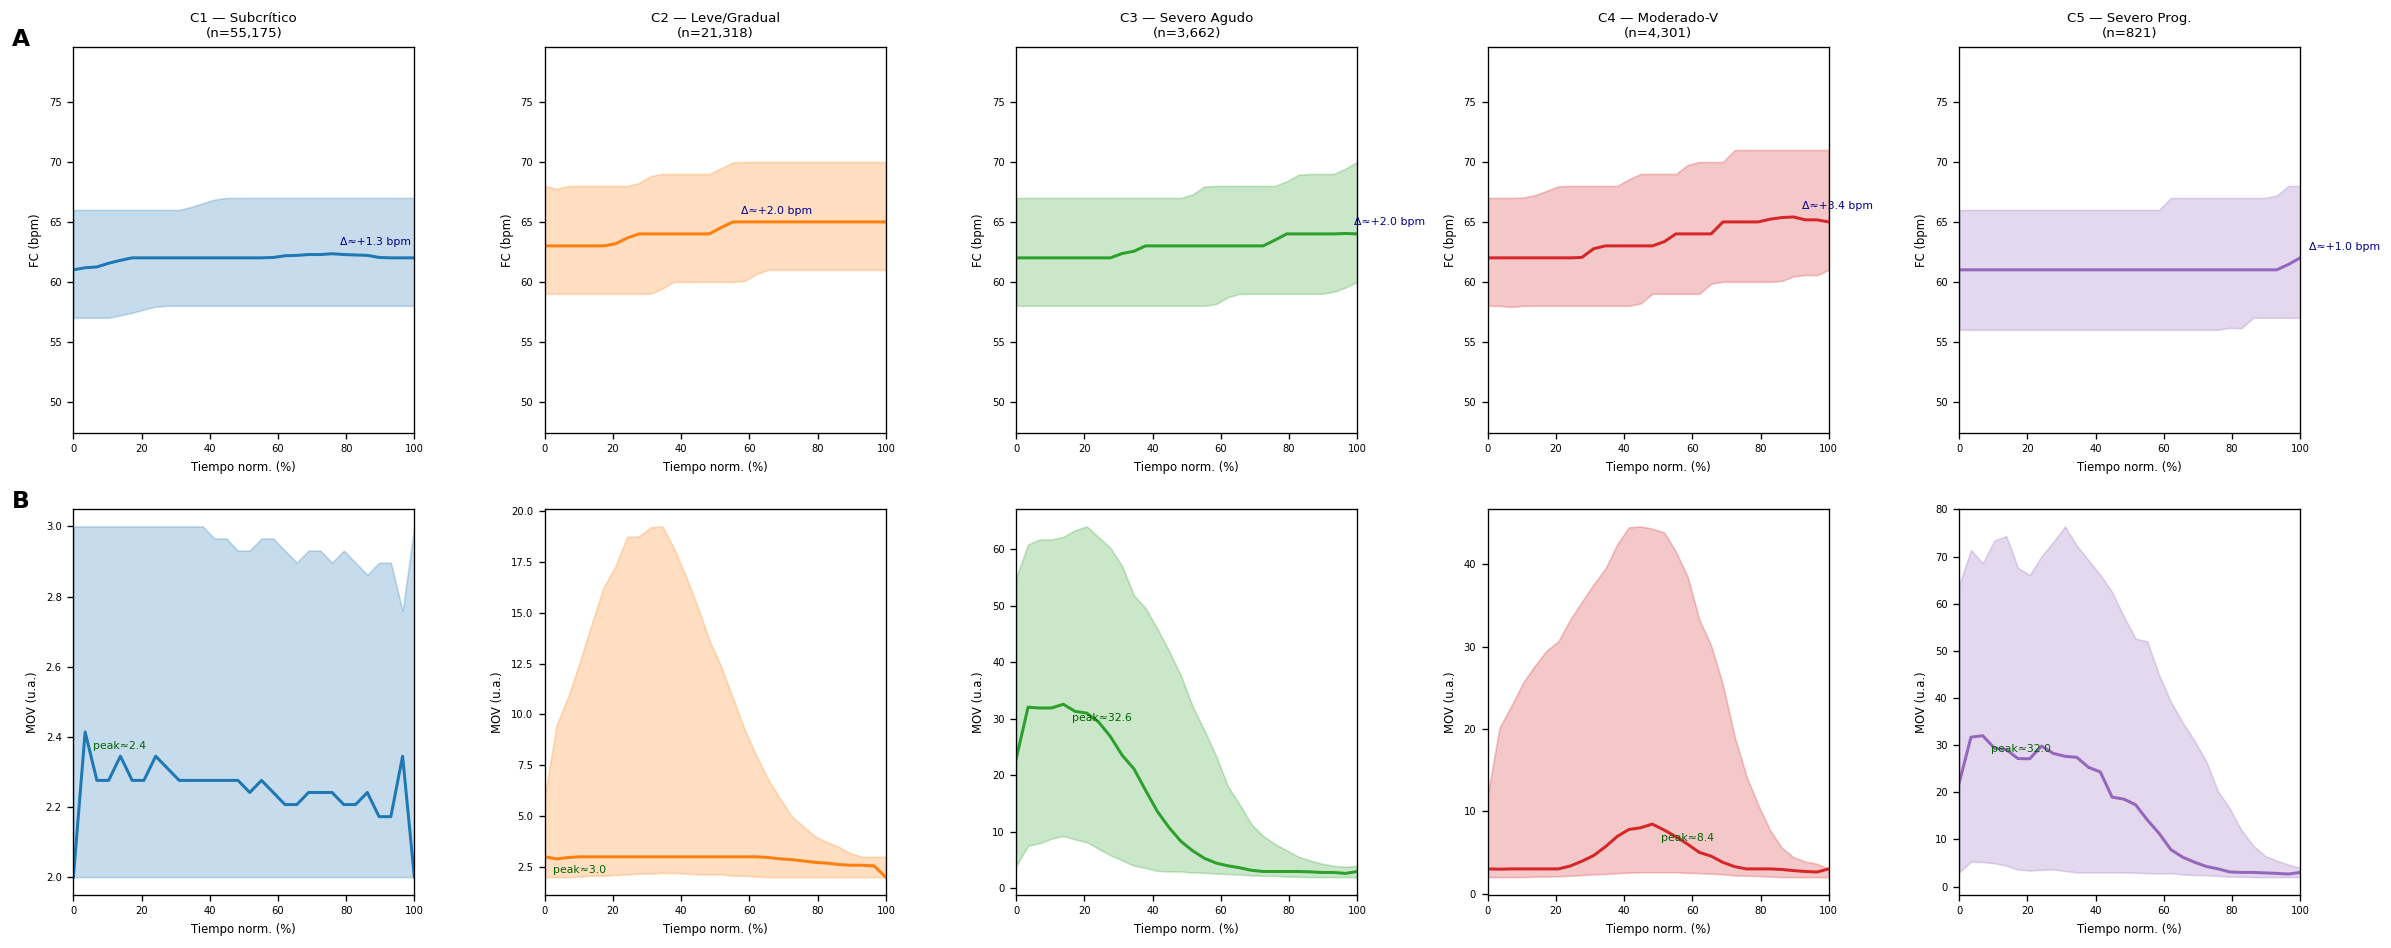

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for col_idx, c in enumerate(cluster_order):
    name, color = cluster_meta[c]
    mask = labels_q2 == c
    n    = mask.sum()
    title = f'{name}\n(n={n:,})'

    # ── Fila 0: FC (HR) ──────────────────────────────────────────────
    ax = axes[0, col_idx]
    curves_hr = hr_q2[mask]
    med_hr = np.nanmedian(curves_hr, axis=0)
    p25_hr = np.nanpercentile(curves_hr, 25, axis=0)
    p75_hr = np.nanpercentile(curves_hr, 75, axis=0)
    ax.fill_between(T, p25_hr, p75_hr, alpha=0.25, color=color)
    ax.plot(T, med_hr, color=color, linewidth=1.8)
    ax.set_xlim(0, 100)
    ax.set_ylim(hr_ylim)
    ax.set_title(title, fontsize=8)
    ax.set_xlabel('Tiempo norm. (%)', fontsize=7)
    ax.set_ylabel('FC (bpm)', fontsize=7)
    ax.tick_params(labelsize=6)
    delta_hr = float(np.nanmax(med_hr) - med_hr[0])
    ax.annotate(f'Δ≈{delta_hr:+.1f} bpm',
                xy=(T[np.nanargmax(med_hr)], np.nanmax(med_hr)),
                xytext=(5, 5), textcoords='offset points',
                fontsize=6.5, color='darkblue')
    if col_idx == 0:
        ax.text(-0.18, 1.05, 'A', transform=ax.transAxes,
                fontsize=14, fontweight='bold', va='top')

    # ── Fila 1: MOV ──────────────────────────────────────────────────
    ax = axes[1, col_idx]
    curves_m = mov_q2[mask]
    med_m = np.nanmedian(curves_m, axis=0)
    p25_m = np.nanpercentile(curves_m, 25, axis=0)
    p75_m = np.nanpercentile(curves_m, 75, axis=0)
    ax.fill_between(T, p25_m, p75_m, alpha=0.25, color=color)
    ax.plot(T, med_m, color=color, linewidth=1.8)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Tiempo norm. (%)', fontsize=7)
    ax.set_ylabel('MOV (u.a.)', fontsize=7)
    ax.tick_params(labelsize=6)
    peak_m = med_m.max()
    ax.annotate(f'peak≈{peak_m:.1f}',
                xy=(T[med_m.argmax()], peak_m),
                xytext=(5, -10), textcoords='offset points',
                fontsize=6.5, color='darkgreen')
    if col_idx == 0:
        ax.text(-0.18, 1.05, 'B', transform=ax.transAxes,
                fontsize=14, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig(FIGDIR / '01_perfiles_fc_mov.png', dpi=180, bbox_inches='tight')
plt.show()

**Interpretación multimodal:**

|Cluster |ΔSpO₂ |FC (ΔHR) |MOV |Fenotipo |
|--------|------|---------|----|---------|
|C1 |−1.7 pp, plana |+1.3 bpm mínimo |2.4 mínimo |Subcrítico — sin respuesta sistémica |
|C2 |−3.9 pp, gradual tardía |+2.0 bpm leve |3.0 mínimoLeve — respuesta autonómica incipiente |
|C3 |−7.1 pp, V rápida |+2.0 bpm leve |32.6 alto |Severo Agudo — arousal marcado, HR leve
|C4 |−8.0 pp, nadir tardío |+3.4 bpm mayor |8.4 moderado |Severo Tardío — respuesta cardiovascular sin arousal completo 
|C5 |−14.2 pp, progresivo |+1.0 bpm mínimo |32.0 alto |Severo Progresivo — arousal alto, HR paradójicamente baja|

**Hallazgo no-monótono:** la respuesta sistémica no escala linealmente con la severidad de SpO₂. Dos patrones disociativos emergen:

- C3 y C5 muestran arousal alto (MOV ~32) pero FC baja — sugieren eventos con despertar pero sin taquicardia compensatoria. En C5 esto puede reflejar adaptación autonómica a hipoxia crónica severa o respuesta vagal paradójica.
- C4 tiene la mayor respuesta de FC (+3.4 bpm) con MOV moderado — evento cardiovascularmente estresante sin despertar completo, potencialmente el fenotipo de mayor riesgo silencioso.
- C1 y C2 confirman bajo impacto sistémico en ambos ejes.

> La disociación HR/MOV entre C3, C4 y C5 es la ganancia clínica más relevante del enfoque multimodal — la SpO₂ sola no distingue estos tres fenotipos de respuesta.


### 9. Conclusiones

**9.1 Estructura morfológica del espacio EDO**
Las 85,277 curvas de ΔSpO₂ (30 puntos de tiempo normalizado) forman un espacio de baja dimensionalidad: 3 PCs explican el 84% de la varianza. Las dimensiones principales son magnitud (PC1, 63%), asimetría temporal (PC2, 14%) y timing del nadir (PC3, 7%).

**9.2 5 morfotipos curva (C1–C5)**
K-means k=5 no es el óptimo estadístico por silhouette (k=2 = 0.644, k=5 = 0.214), pero es la elección clínica: k=5 separa C3 y C4 — dos fenotipos con profundidad similar pero timing opuesto que k=4 colapsa en un solo cluster. Los 5 clusters cubren el espectro de severidad con distinción multimodal:

- **C1 Subcrítico (64.7%, nadir −1.7 pp):** bajo impacto, sin respuesta sistémica en FC ni MOV.
- **C2 Leve/Gradual (25.0%, nadir −3.9 pp):** descenso gradual tardío, respuesta autonómica mínima.
- **C3 Severo Agudo (4.3%, nadir −7.1 pp):** caída rápida a nadir precoz con recuperación lenta y prolongada, arousal alto (MOV ~32), FC moderada.
- **C4 Severo Tardío (5.0%, nadir −8.0 pp):** descenso gradual a nadir tardío con recuperación abrupta, mayor respuesta de FC (+3.4 bpm) con arousal moderado — fenotipo de mayor estrés cardiovascular silencioso.
- **C5 Severo Progresivo (1.0%, nadir −14.2 pp):** descenso sostenido y profundo, arousal alto (MOV ~32) pero FC paradójicamente baja (+1.0 bpm) — posible adaptación autonómica a hipoxia crónica severa.

**9.3 Hallazgo no-monótono FC/MOV**
La respuesta sistémica no escala linealmente con severidad de SpO₂. C4 tiene la mayor respuesta cardiovascular sin arousal completo; C3 y C5 tienen alto arousal sin taquicardia compensatoria. La SpO₂ sola no distingue estos tres fenotipos de respuesta — la multimodalidad es esencial.

**9.4 Ganancia sobre morfotipos rule-based (10 clases α–κ)**
- **β → C1 (87%)** y **δ → C5 (83%)**: los extremos del espectro están bien capturados por ambos sistemas — validación cruzada consistente.
- **ε → C3 (68%)** e **ι → C4 (48%)**: morfotipos rule-based específicos mapean limpiamente a clusters severos con timing distinto.
- **α, ζ fragmentados en C2/C3/C4** y **θ en C3+C4+C5**: el sistema rule-based capturaba profundidad pero no timing — exactamente lo que el clustering sobre curvas agrega.

**9.5 Estabilidad y uso en pipeline**
- Estabilidad bootstrap: **76.2%** (10 runs, 80% muestra, MiniBatch) — lower bound conservador; C5 muestra varianza extrema por su tamaño reducido (n=821).
- Modelo de producción (KMeans full, `random_state=42`) guardado en `models/`. Columna `morphotype_curve` materializada en `gold/events.parquet`. Idempotente y determinista.
- Feature derivada `morphotype_severity` (low=C1+C2, high=C3+C4+C5) disponible en `gold/events_analysis.parquet`.

**9.6 Próximo paso**
NB02: definición y validación del ARI (Índice de Respuesta Autonómica) usando los clusters C1–C5 como referencia de severidad morfológica y contexto de respuesta multimodal.



## 10. Estabilidad noche-a-noche dentro del paciente

**Pregunta clínica clave:** ¿el morfotipo curva es un *rasgo del paciente* o un *rasgo del evento/noche*?
Esto determina si se puede resumir a nivel paciente o si hay que modelar con efectos mixtos.

Métrica usada: **ICC(1,1)** (intraclass correlation, one-way random) sobre la fracción de
eventos en cada cluster por noche. Un ICC alto → la varianza entre pacientes domina sobre la
varianza intra-paciente → es un rasgo del paciente.


In [15]:
valid = df_q2.copy()

# Per-night cluster distribution
per_night = (
    valid.groupby('night_record_id')['morphotype_curve']
    .value_counts(normalize=True).unstack(fill_value=0)
    .reindex(columns=['C1','C2','C3','C4','C5'], fill_value=0)
)
per_night['n_events'] = valid.groupby('night_record_id').size()
per_night['user_id']  = valid.groupby('night_record_id')['user_id'].first()
per_night = per_night.reset_index()

patients_stab = [p for p in sorted(valid['user_id'].unique())
                 if per_night[per_night['user_id']==p].shape[0] >= 10]
print(f'Pacientes con ≥10 noches: {len(patients_stab)}')
print(f'Noches totales: {len(per_night)}')



Pacientes con ≥10 noches: 8
Noches totales: 560



ICC(1,1):
  C1: 0.601
  C2: 0.682
  C3: 0.419
  C4: 0.476
  C5: 0.505


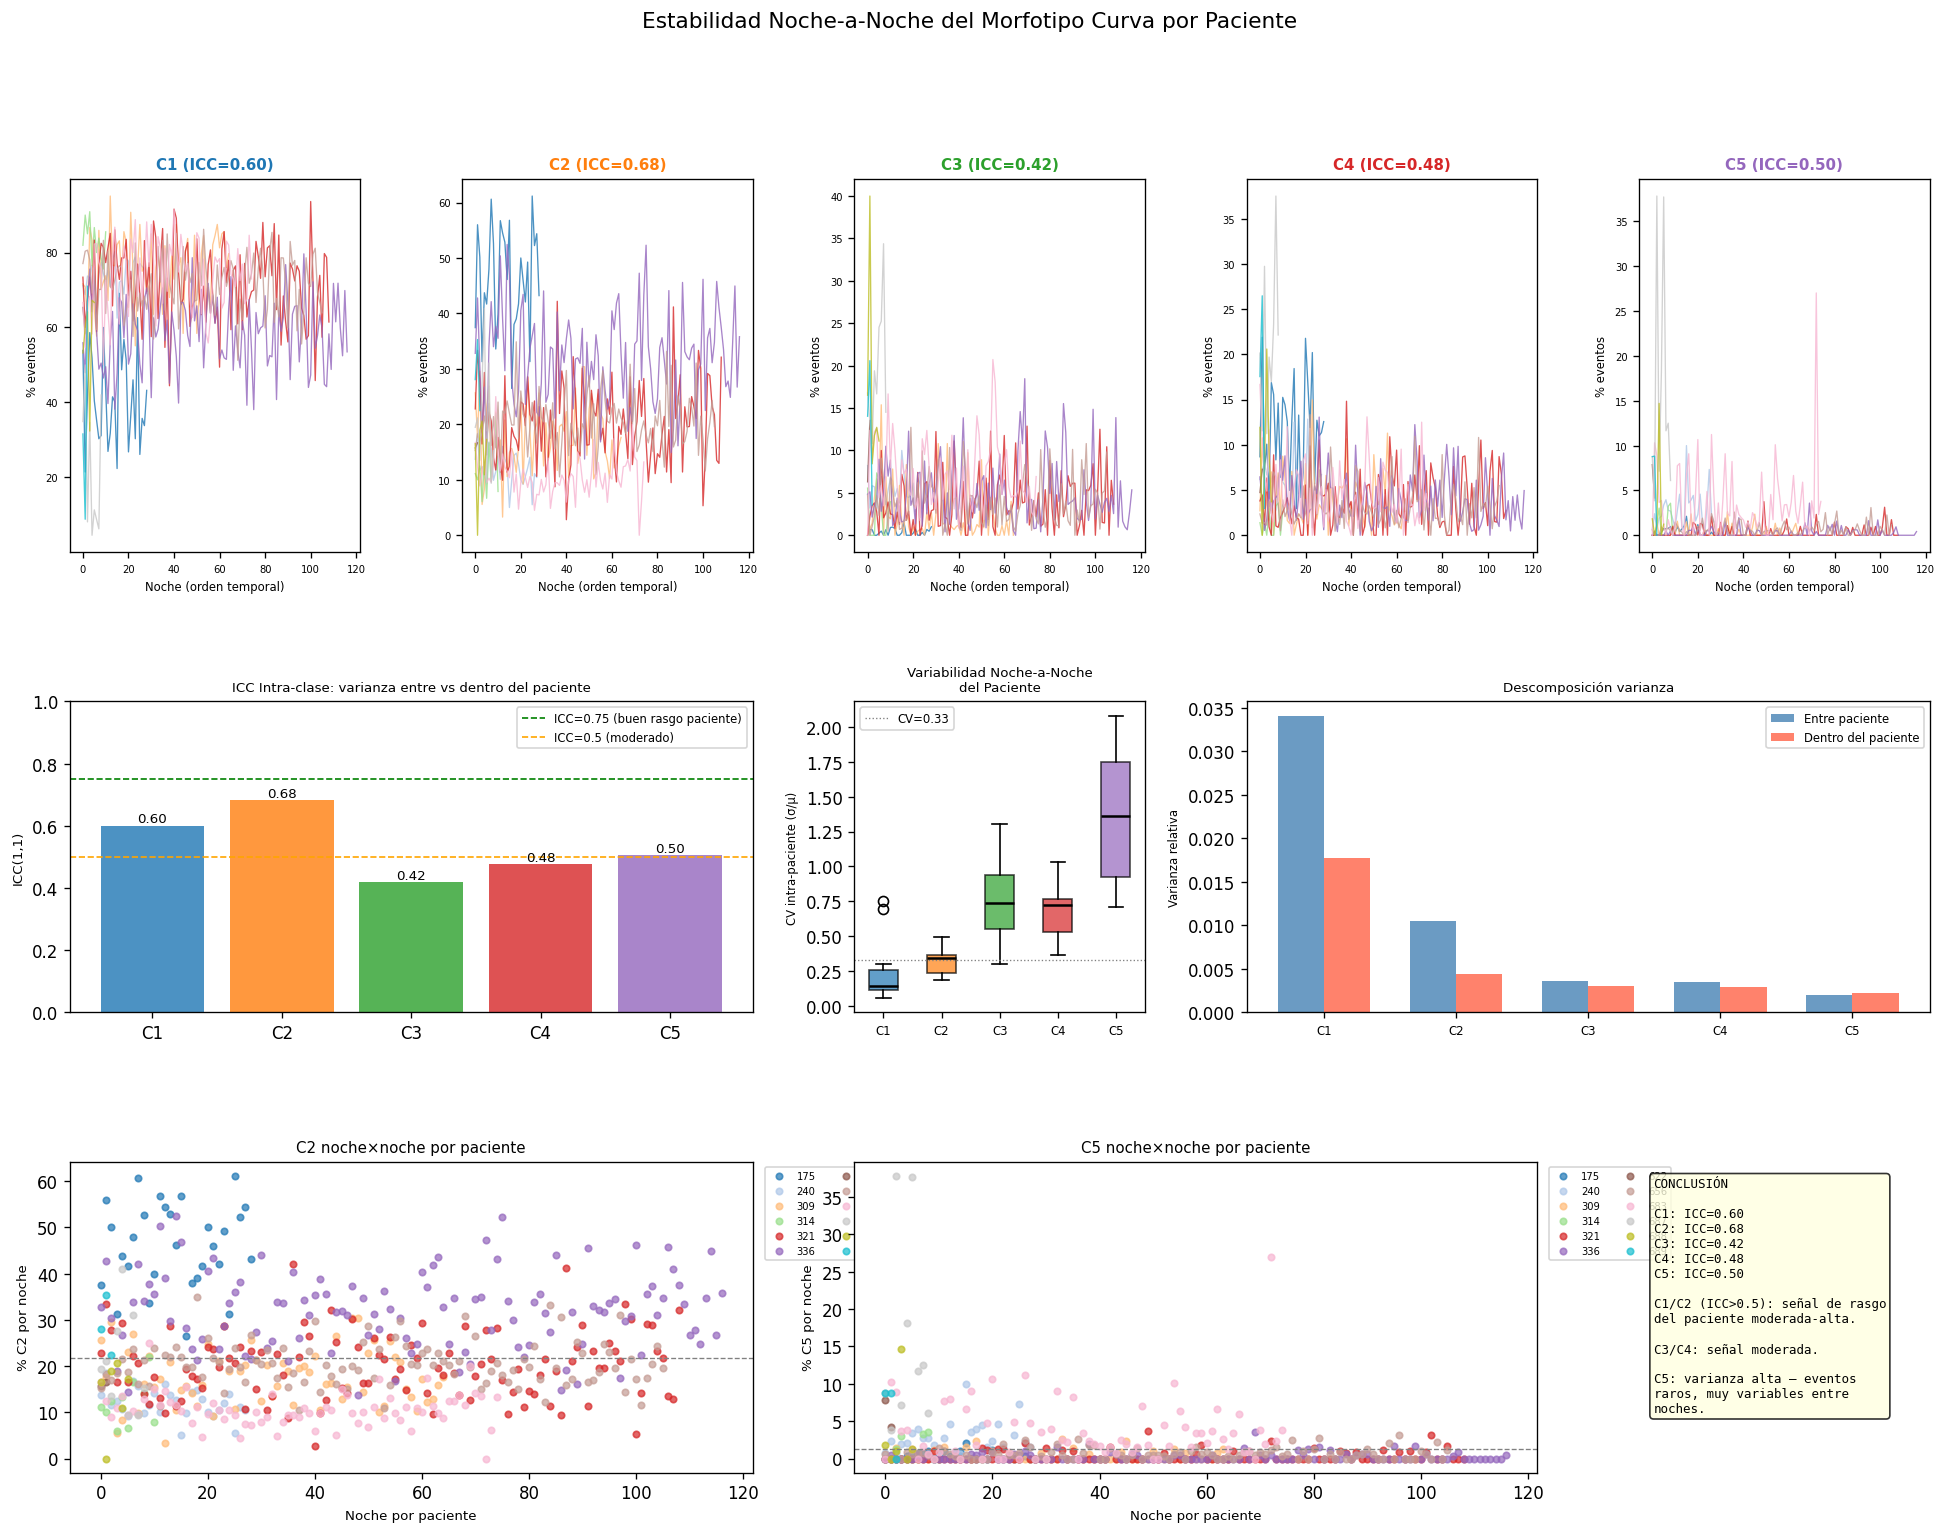

In [16]:
# ICC(1,1)
def icc11(df, group_col, val_col):
    groups, y = df[group_col].values, df[val_col].values.astype(float)
    ug = np.unique(groups); n, k = len(y), len(ug)
    gm = y.mean()
    SS_b = sum(((y[groups==g].mean()-gm)**2)*(groups==g).sum() for g in ug)
    SS_w = sum(((y[groups==g]-y[groups==g].mean())**2).sum() for g in ug)
    MS_b, MS_w = SS_b/(k-1), SS_w/(n-k)
    ns = np.array([(groups==g).sum() for g in ug])
    n0 = (n - (ns**2).sum()/n)/(k-1)
    return (MS_b-MS_w)/(MS_b+(n0-1)*MS_w)

icc_vals = {c: icc11(per_night, 'user_id', c) for c in cluster_order}
print('\nICC(1,1):')
for c, v in icc_vals.items():
    print(f'  {c}: {v:.3f}')

# Paleta de pacientes
pat_list = sorted(valid['user_id'].unique())
pat_colors = {p: plt.cm.tab20(i/len(pat_list)) for i, p in enumerate(pat_list)}

# CV intra-paciente por cluster
def cv_intra(df_pn, cluster, patients):
    cvs = []
    for p in patients:
        vals = df_pn[df_pn['user_id']==p][cluster].values
        if len(vals) >= 3 and vals.mean() > 0:
            cvs.append(vals.std() / vals.mean())
    return cvs

cv_data = {c: cv_intra(per_night, c, pat_list) for c in cluster_order}

# Varianza entre vs dentro del paciente
def var_decomp(df_pn, cluster):
    between = df_pn.groupby('user_id')[cluster].mean().var()
    within  = df_pn.groupby('user_id')[cluster].var().mean()
    return between, within

var_b = {c: var_decomp(per_night, c)[0] for c in cluster_order}
var_w = {c: var_decomp(per_night, c)[1] for c in cluster_order}

# ── Figura ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Estabilidad Noche-a-Noche del Morfotipo Curva por Paciente', fontsize=13)

gs = fig.add_gridspec(3, 5, hspace=0.45, wspace=0.35,
                      height_ratios=[1.2, 1, 1])

# ── Fila 0: series temporales por cluster ──────────────────────────────
for col_idx, c in enumerate(cluster_order):
    ax = fig.add_subplot(gs[0, col_idx])
    icc_v = icc_vals[c]
    ax.set_title(f'{c} (ICC={icc_v:.2f})', fontsize=9,
                 color=cluster_colors[c], fontweight='bold')
    for p in pat_list:
        pdata = per_night[per_night['user_id']==p].reset_index(drop=True)
        if len(pdata) >= 2:
            ax.plot(range(len(pdata)), pdata[c]*100,
                    color=pat_colors[p], linewidth=0.8, alpha=0.8, label=p)
    ax.set_xlabel('Noche (orden temporal)', fontsize=7)
    ax.set_ylabel('% eventos', fontsize=7)
    ax.tick_params(labelsize=6)

# ── Fila 1: ICC bars / CV boxplot / varianza descomp ───────────────────
# ICC barras
ax_icc = fig.add_subplot(gs[1, :2])
bar_colors_icc = [cluster_colors[c] for c in cluster_order]
bars = ax_icc.bar(cluster_order, [icc_vals[c] for c in cluster_order],
                   color=bar_colors_icc, alpha=0.8)
for bar, c in zip(bars, cluster_order):
    ax_icc.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{icc_vals[c]:.2f}', ha='center', fontsize=8)
ax_icc.axhline(0.75, color='green', linestyle='--', linewidth=1,
               label='ICC=0.75 (buen rasgo paciente)')
ax_icc.axhline(0.5,  color='orange', linestyle='--', linewidth=1,
               label='ICC=0.5 (moderado)')
ax_icc.set_ylabel('ICC(1,1)', fontsize=8)
ax_icc.set_title('ICC Intra-clase: varianza entre vs dentro del paciente', fontsize=8)
ax_icc.set_ylim(0, 1)
ax_icc.legend(fontsize=7)

# CV boxplot
ax_cv = fig.add_subplot(gs[1, 2])
bp = ax_cv.boxplot([cv_data[c] for c in cluster_order],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], cluster_order):
    patch.set_facecolor(cluster_colors[c]); patch.set_alpha(0.7)
ax_cv.set_xticklabels(cluster_order, fontsize=7)
ax_cv.set_ylabel('CV intra-paciente (σ/μ)', fontsize=7)
ax_cv.set_title('Variabilidad Noche-a-Noche\ndel Paciente', fontsize=8)
ax_cv.axhline(0.33, color='gray', linestyle=':', linewidth=0.8, label='CV=0.33')
ax_cv.legend(fontsize=7)

# Varianza descomposición
ax_var = fig.add_subplot(gs[1, 3:])
x = np.arange(len(cluster_order))
w = 0.35
ax_var.bar(x - w/2, [var_b[c] for c in cluster_order], w,
           label='Entre paciente', color='steelblue', alpha=0.8)
ax_var.bar(x + w/2, [var_w[c] for c in cluster_order], w,
           label='Dentro del paciente', color='tomato', alpha=0.8)
ax_var.set_xticks(x); ax_var.set_xticklabels(cluster_order, fontsize=7)
ax_var.set_ylabel('Varianza relativa', fontsize=7)
ax_var.set_title('Descomposición varianza', fontsize=8)
ax_var.legend(fontsize=7)

# ── Fila 2: scatter C2 y C5 por paciente ──────────────────────────────
for col_idx, c in enumerate(['C2', 'C5']):
    ax = fig.add_subplot(gs[2, col_idx*2:(col_idx*2)+2])
    for p in pat_list:
        pdata = per_night[per_night['user_id']==p]
        nights_idx = range(len(pdata))
        ax.scatter(nights_idx, pdata[c]*100, color=pat_colors[p],
                   s=15, alpha=0.7, label=p)
    ax.axhline(per_night[c].mean()*100, color='gray',
               linestyle='--', linewidth=0.8)
    ax.set_xlabel('Noche por paciente', fontsize=8)
    ax.set_ylabel(f'% {c} por noche', fontsize=8)
    ax.set_title(f'{c} noche×noche por paciente', fontsize=9)
    ax.legend(fontsize=6, ncol=2, bbox_to_anchor=(1.01,1), loc='upper left')

# Conclusión textual
ax_txt = fig.add_subplot(gs[2, 4])
ax_txt.axis('off')
icc_str = '\n'.join([f'{c}: ICC={icc_vals[c]:.2f}' for c in cluster_order])
conclusion = (
    f"CONCLUSIÓN\n\n{icc_str}\n\n"
    "C1/C2 (ICC>0.5): señal de rasgo\ndel paciente moderada-alta.\n\n"
    "C3/C4: señal moderada.\n\n"
    "C5: varianza alta — eventos\nraros, muy variables entre\nnoches."
)
ax_txt.text(0.05, 0.95, conclusion, transform=ax_txt.transAxes,
            fontsize=7.5, va='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.savefig(FIGDIR / '01_estabilidad_noche_paciente.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretación

| Cluster | ICC | CV intra-paciente | Conclusión |
|---------|-----|-------------------|------------|
| C1 | 0.60 | ~25% | **Rasgo moderado del paciente** — fracción subcrítica relativamente estable entre noches |
| C2 | 0.68 | ~30% | **Rasgo moderado-alto** — mejor predictor a nivel paciente de todos los clusters |
| C3 | 0.42 | ~75% | **Mixto** — ariabilidad nocturna alta, señal de paciente presente pero débil |
| C4 | 0.48 | ~75% | **Mixto** — ídem C3, componente nocturno relevante |
| C5 | 0.50 | ~150% | **Moderado con alta dispersión** — eventos raros y muy variables noche a noche; el CV >1 refleja que algunas noches tienen 0 eventos C5 |

**Implicaciones para el pipeline:**

- **C1 y C2** pueden usarse como features a nivel paciente (resumen de noches) con ICC>0.5 y CV moderado.
- **C3/C4** requieren modelado con efectos mixtos (patient como random effect) — la variabilidad nocturna es real y clínicamente informativa.
- **C5** es un caso especial: ICC moderado (0.50) pero CV extremo (~150%) por su baja frecuencia. Muchas noches tienen 0 eventos C5 — esto genera inestabilidad en el CV pero no invalida la señal del paciente.
- La varianza entre pacientes domina claramente en C1 (descomposición: entre >> dentro) y decrece hacia C3–C5, donde ambas componentes son similares.
- La noche como unidad de análisis está justificada: ICC < 0.75 en todos los clusters indica que la noche aporta información incremental más allá del fenotipo del paciente. Esto confirma la decisión de usar las 560 noches quality como eje principal de análisis.
